
# Exploratory Data Analysis (EDA)

## Project
Predicting Student Dropout Risk in Online Learning Platforms

## Objective
The objective of this Exploratory Data Analysis (EDA) is to understand the Open University Learning Analytics Dataset (OULAD), assess data quality, identify patterns associated with student engagement and performance, and discover relationships that may influence student dropout. The insights obtained from this analysis will guide data preprocessing, feature engineering, and predictive model development.

In [1]:
%pip install pandas numpy matplotlib seaborn kagglehub

  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached charset_normalizer-3.4.9-cp314-cp314-win_amd64.whl.metadata (42 kB)
  U

In [2]:
#Import Libraries
import kagglehub
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

c:\Users\jaypr\Desktop\eMasters\Student Dropout-Capstone Project-Group\iiith-capstone-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Download Dataset

In [3]:
path = kagglehub.dataset_download(
    "anlgrbz/student-demographics-online-education-dataoulad"
)

print("Path to dataset:", path)

Path to dataset: C:\Users\jaypr\.cache\kagglehub\datasets\anlgrbz\student-demographics-online-education-dataoulad\versions\1


### Loading the DataSet: Read CSV Files

Each file stores different information.

DataFrame	Information
df_students	Student demographics & final result
df_studentAssessment	Assessment marks
df_assessments	Assessment details
df_studentRegistration	Registration & withdrawal
df_studentVle	Student clickstream
df_vle	Learning resources
df_courses	Course information

Later, these datasets will be joined using keys such as

id_student
id_assessment
code_module
code_presentation


In [4]:
df_assessments = pd.read_csv(path + '\\assessments.csv') #assessments-Assessment details
df_assessments.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [5]:
print(df_assessments.shape) 
print(df_assessments.info()) 

(206, 6)
<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    str    
 1   code_presentation  206 non-null    str    
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    str    
 4   date               195 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 9.8 KB
None


In [6]:
df_courses = pd.read_csv(path + '\\courses.csv') #courses-Course information
df_courses.head()

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [7]:
print(df_courses.shape) 
print(df_courses.info()) 

(22, 3)
<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   code_module                 22 non-null     str  
 1   code_presentation           22 non-null     str  
 2   module_presentation_length  22 non-null     int64
dtypes: int64(1), str(2)
memory usage: 660.0 bytes
None


In [8]:
df_studentAssessments = pd.read_csv(path + '\\studentAssessment.csv') #studentAssessment-Student marks
df_studentAssessments.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [9]:
print(df_studentAssessments.shape)
print(df_studentAssessments.info())

(173912, 5)
<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB
None


In [10]:
df_students = pd.read_csv(path + '\\studentInfo.csv') #Student demographics & final result
df_students.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [11]:
print(df_students.shape)
print(df_students.info())

(32593, 12)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB
None


In [12]:
df_studentRegistration = pd.read_csv(path + '\\studentRegistration.csv') #Registration & withdrawal
df_studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [13]:
print(df_studentRegistration.shape)
print(df_studentRegistration.info())

(32593, 5)
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB
None


In [14]:
df_studentVle = pd.read_csv(path + '\\studentVle.csv') #Clickstream activity
df_studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [15]:
print(df_studentVle.shape)
print(df_studentVle.info())

(10655280, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB
None


In [16]:
df_vle = pd.read_csv(path + '\\vle.csv') #Learning resource details
df_vle.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [17]:
print(df_vle.shape)
print(df_vle.info())

(6364, 6)
<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   str    
 2   code_presentation  6364 non-null   str    
 3   activity_type      6364 non-null   str    
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 298.4 KB
None


In [18]:
print("="*60)
print("Dataset Shapes")
print("="*60)

print("Assessments:", df_assessments.shape)
print("Courses:", df_courses.shape)
print("Student Assessment:", df_studentAssessments.shape)
print("Student Info:", df_students.shape)
print("Student Registration:", df_studentRegistration.shape)
print("Student VLE:", df_studentVle.shape)
print("VLE:", df_vle.shape)

Dataset Shapes
Assessments: (206, 6)
Courses: (22, 3)
Student Assessment: (173912, 5)
Student Info: (32593, 12)
Student Registration: (32593, 5)
Student VLE: (10655280, 6)
VLE: (6364, 6)


### Data Quality Assessment
Objective

Before building any Machine Learning model, we ask these questions:

How big is each dataset?
What columns are available?
What is the data type of each column?
Are there missing values?
Are there duplicate rows?
Is the dataset ready for analysis?

Instead of writing the same code for all 7 datasets, we created a helper function.

Why we check shape
Why data types matter for machine learning
Why we look for missing values
Why duplicates can affect model performance
How to interpret the actual OULAD outputs (e.g., why studentVle has over 10 million rows and why date_unregistration contains many missing values).

Overall Purpose of this Function

This function answers five questions for every dataset.

Question:	
Why it matters
How big is the dataset?	Shape
What information does it contain?	Columns
What type of data is present?	Data types
Is any data missing?	Null values
Is any data duplicated?	Duplicate rows

This is exactly the objective of the Data Understanding phase in EDA.

In [19]:
# Define a helper to summarize each dataframe

def summarize_df(df, name):
    print(f"=== {name} ===")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    print("dtypes:")
    print(df.dtypes)
    print("\nUnique Values:")
    print(df.nunique())
    print("\nMemory Usage:") #Added By Kiran
    print(f"{df.memory_usage(deep=True).sum()/1024**2:.2f} MB") #Added By Kiran
    print("\nnull counts:")
    print(df.isna().sum().sort_values(ascending=False).head(30))
    print("\nMissing Percentage (%):") #Added By Kiran
    missing_percent = (df.isna().sum() / len(df)) * 100 #Added By Kiran
    print(missing_percent.sort_values(ascending=False).round(2).head(30)) #Added By Kiran
    print("duplicate rows:", df.duplicated().sum())
    print("\n")

for name, df in [
    ("assessments", df_assessments),
    ("courses", df_courses),
    ("studentAssessment", df_studentAssessments),
    ("studentInfo", df_students),
    ("studentRegistration", df_studentRegistration),
    ("studentVle", df_studentVle),
    ("vle", df_vle),
]:
    summarize_df(df, name)

=== assessments ===
shape: (206, 6)
columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
dtypes:
code_module              str
code_presentation        str
id_assessment          int64
assessment_type          str
date                 float64
weight               float64
dtype: object

Unique Values:
code_module            7
code_presentation      4
id_assessment        206
assessment_type        3
date                  74
weight                24
dtype: int64

Memory Usage:
0.04 MB

null counts:
date                 11
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
weight                0
dtype: int64

Missing Percentage (%):
date                 5.34
code_module          0.00
code_presentation    0.00
id_assessment        0.00
assessment_type      0.00
weight               0.00
dtype: float64
duplicate rows: 0


=== courses ===
shape: (22, 3)
columns: ['code_module', 'code_presentation', 'm

### Assessments Analysis

In this section we are analyzin assessments.csv in depth—not just explain the code, but answer questions like:

What is a TMA, CMA, and Exam?
Why do some assessments have 0% weight?
Why are assessment weights important for predicting dropout?
How should we interpret the histograms and count plots

This is where we begin extracting insights from the data rather than just checking its quality.

## Objective

The file assessments.csv contains information about every assessment (assignment, coursework, exam) offered in each course.

Before predicting whether a student will drop out, we need to understand:

How many assessments does each course have?
What types of assessments exist?
How much does each assessment contribute to the final grade?
When are assessments conducted?
Are there any missing values?

These questions are important because assessment workload and performance strongly influence student engagement and dropout risk.

Step 1 – Display First Five Rows: df_assessments.head()

Output

code_module	code_presentation	id_assessment	assessment_type	date	weight
AAA	2013J	1752	TMA	19	10
AAA	2013J	1753	TMA	54	20
AAA	2013J	1754	TMA	117	20
AAA	2013J	1755	TMA	166	20
AAA	2013J	1756	TMA	215	30

Understanding Every Column
1. code_module

Example
AAA
BBB
CCC
DDD

Think of this as the Course ID.Instead of writing 'Machine Learning',they simply use 'AAA'. Every course has a unique code.

2. code_presentation

Example
2013J
2014B
2014J

Means Course offering:

2013 = Year
J = January presentation
B = February presentation (presentation code used by Open University)

One course can be offered multiple times.

3. id_assessment

Example
1752
1753
1754
Every assessment has its own unique ID.

Later, 'studentAssessment.csv' uses this same ID.That's how we connect

Assessment

↓

Student Score

4. assessment_type

Example
TMA
CMA
Exam

TMA: Tutor Marked Assignment.Normal assignment.Submitted during the course.Usually contributes to the final grade.

CMA:Computer Marked Assessment.Automatically graded.Usually MCQs,Programming quizzes,Online quizzes

Exam:Final examination.Usually has the highest importance.

## Why is this important?

Later,we'll compare

Average Score

↓

Assessment Type

Maybe Students perform poorly in Exams or TMAs

That becomes a useful feature.

5. Date

Example
19
54
117

This is NOT Calendar date.It means Days from course start.

Example

19

↓

Assessment is due 19 days after the course begins.

## Why is date important?

Students who stop submitting assessments early are often at high risk of dropping out.

6. Weight

Example
10
20
30
100

Weight means Contribution towards Final Grade.

Example: Suppose Assignment 1,Weight = 20

Assignment 2,Weight = 30

Exam,Weight = 50

Total=100%




# Assessments analysis
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
assessment_type
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

Assessment Type Percentage
assessment_type
TMA     51.46
CMA     36.89
Exam    11.65
Name: proportion, dtype: float64
count    206.000000
mean      20.873786
std       30.384224
min        0.000000
25%        0.000000
50%       12.500000
75%       24.250000
max      100.000000
Name: weight, dtype: float64

Average Weight by Assessment Type
                 count    mean  median    min    max
assessment_type                    

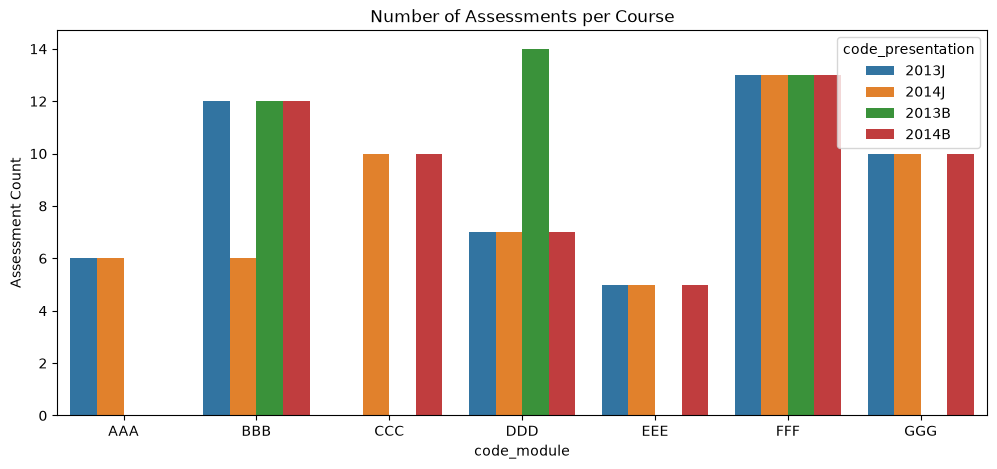

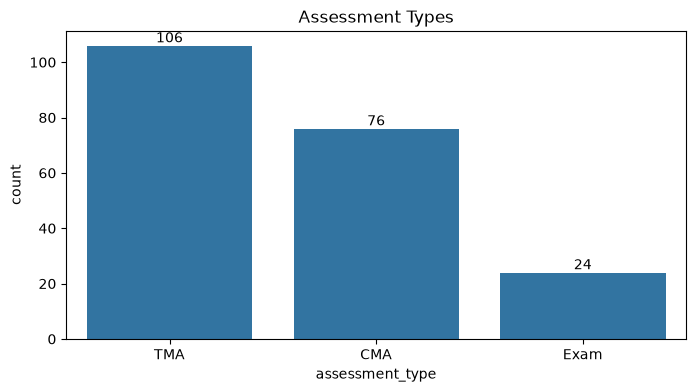

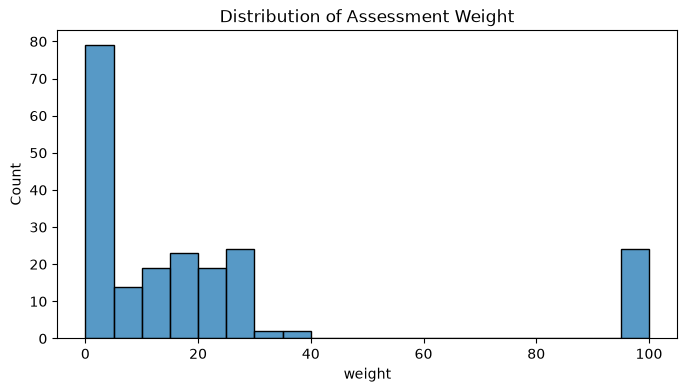

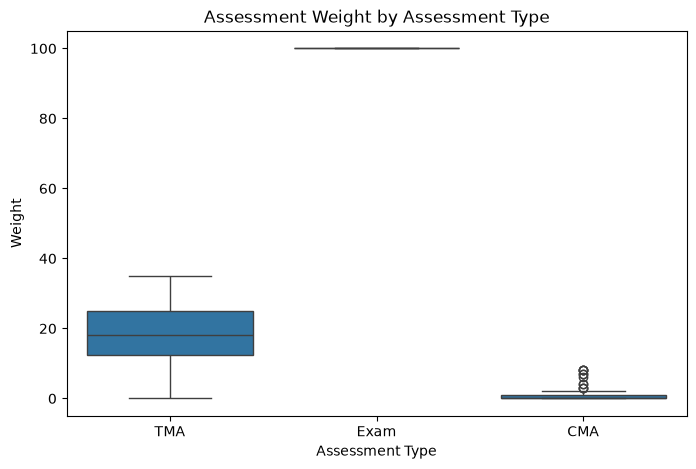

In [20]:
# Assessments analysis
print("# Assessments analysis")
print(df_assessments.head())
print(df_assessments['assessment_type'].value_counts())
print("\nAssessment Type Percentage") #Added By Kiran
print(
    round(
        df_assessments['assessment_type']
        .value_counts(normalize=True) * 100,
        2
    )
)#Added By Kiran
print(df_assessments['weight'].describe())
print("\nAverage Weight by Assessment Type") #Added By Kiran
print(
    df_assessments.groupby("assessment_type")["weight"]
                  .agg(["count", "mean", "median", "min", "max"])
                  .round(2)
) #Added By Kiran
print('missing dates:', df_assessments['date'].isna().sum())
missing = df_assessments["date"].isna().mean() * 100 #Added By Kiran
print(f"Missing Date Percentage : {missing:.2f}%") #Added By Kiran
print(df_assessments.groupby(['code_module', 'code_presentation'])['id_assessment'].nunique().sort_values(ascending=False).head(20))
#Added By Kiran
assessment_counts = (
    df_assessments
    .groupby(["code_module","code_presentation"])
    ["id_assessment"]
    .count()
    .reset_index()
)

plt.figure(figsize=(12,5))

sns.barplot(
    data=assessment_counts,
    x="code_module",
    y="id_assessment",
    hue="code_presentation"
)

plt.title("Number of Assessments per Course")
plt.ylabel("Assessment Count")
plt.show()
#######
plt.figure(figsize=(8, 4))
sns.countplot(data=df_assessments, x='assessment_type', order=df_assessments['assessment_type'].value_counts().index)
for container in plt.gca().containers: #Added By Kiran
    plt.bar_label(container)
df_assessments.groupby("assessment_type")["weight"].mean()
plt.title('Assessment Types')
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_assessments['weight'].dropna().astype(float), bins=20, kde=False)
plt.title('Distribution of Assessment Weight')
plt.xlabel('weight')
plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_assessments,
    x="assessment_type",
    y="weight"
)

plt.title("Assessment Weight by Assessment Type")
plt.xlabel("Assessment Type")
plt.ylabel("Weight")
plt.show()

### Conclusion from Assessment Analysis:
The assessment analysis shows that the OULAD courses primarily rely on continuous assessment through Tutor Marked Assignments, while final examinations carry the highest individual weight. Assessment workload varies across course presentations, and most assessment dates are available for analysis. These characteristics provide valuable contextual information about course design and evaluation structure. When combined with student performance data in later stages, assessment type, timing, and weight may help identify patterns associated with student engagement and dropout risk.

### Courses Dataset Analysis
The courses.csv file stores course-level information, not student-level information.

Each row represents one course presentation.

Example:

code_module	code_presentation	module_presentation_length
AAA	2013J	268
BBB	2014B	240

Notice there is:

No student ID
No assessment score
No clickstream

It simply tells us:

Which course is being offered
Which presentation (semester)
How long the course runs

Later, this table is merged with student information using:

code_module & code_presentation

# Courses analysis
  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240
       code_module code_presentation  module_presentation_length
count           22                22                   22.000000
unique           7                 4                         NaN
top            BBB             2014J                         NaN
freq             4                 7                         NaN
mean           NaN               NaN                  255.545455
std            NaN               NaN                   13.654677
min            NaN               NaN                  234.000000
25%            NaN               NaN                  241.000000
50%            NaN               NaN

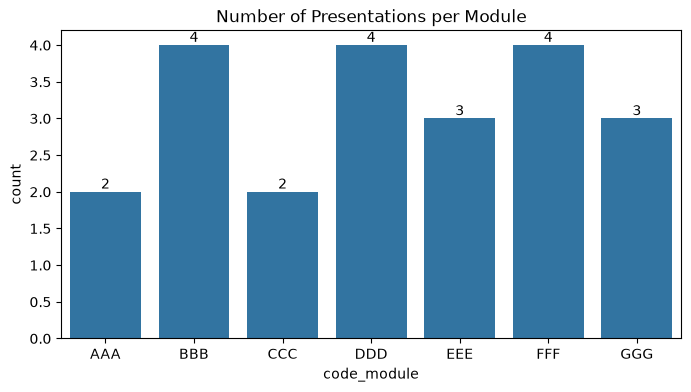

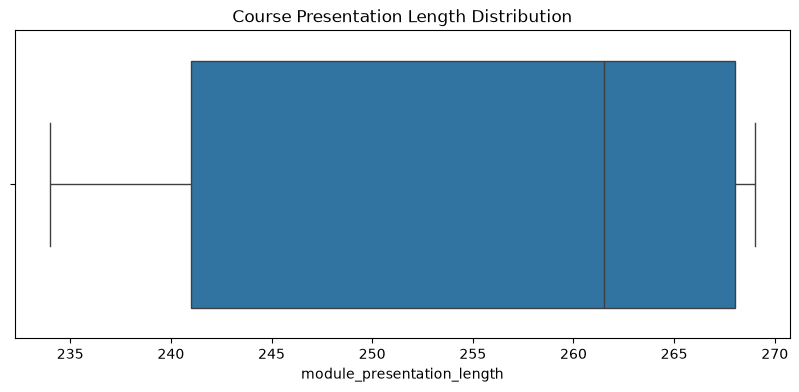

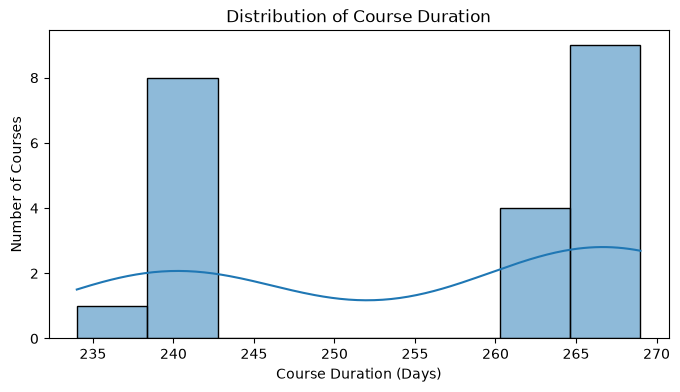

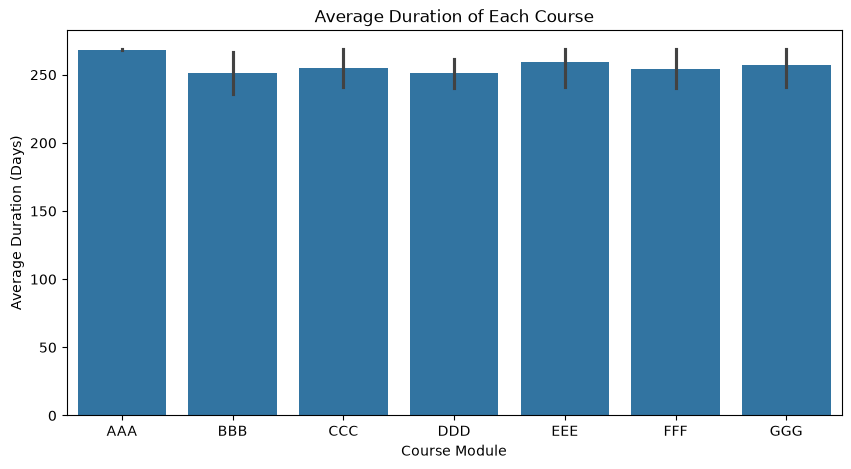

In [21]:
# Courses analysis
print("# Courses analysis")
print(df_courses.head())
print(df_courses.describe(include='all'))
print('unique module/presentation combos:', df_courses.groupby(['code_module', 'code_presentation']).size().shape[0])
print(df_courses.groupby('code_module')['module_presentation_length'].describe())

#Added By Kiran
print("\nPresentations per Module")

print(
    df_courses["code_module"]
              .value_counts()
) 

plt.figure(figsize=(8,4))

sns.countplot(
    data=df_courses,
    x="code_module"
)

plt.title("Number of Presentations per Module")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()
#Added By Kiran
plt.figure(figsize=(10, 4))
sns.boxplot(data=df_courses, x='module_presentation_length')
plt.title('Course Presentation Length Distribution')
plt.show()

#Added By Kiran
plt.figure(figsize=(8,4))

sns.histplot(
    df_courses["module_presentation_length"],
    bins=8,
    kde=True
)

plt.title("Distribution of Course Duration")
plt.xlabel("Course Duration (Days)")
plt.ylabel("Number of Courses")
plt.show()

#Comparing Modules-Added By Kiran
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_courses,
    x="code_module",
    y="module_presentation_length",
    estimator="mean"
)

plt.title("Average Duration of Each Course")
plt.xlabel("Course Module")
plt.ylabel("Average Duration (Days)")
plt.show()


### Conclusion from Course Analysis:

Course duration ranges from 234 to 269 days with relatively small variation across modules.

Since longer courses may require sustained engagement, module duration could later be explored as a potential predictor of student dropout after merging with student-level data.

### Student Information Dataset Analysis
StudentInfo dataset contains one row per student per course presentation.

id_student	gender	age_band	highest_education	imd_band	disability	final_result
11391	M	35-55	HE Qualification	80-90%	N	Pass

This dataset contains:

Student demographics
Education background
Socioeconomic status
Disability status
Final course outcome

This is the dataset that will later become our main ML dataset.

This dataset important because almost every feature here can influence dropout.

For example,
Feature	Can affect dropout?
Age	Yes
Gender	Possibly
Education	Yes
Region	Possibly
IMD Band	Yes
Disability	Yes
Credits Studied	Yes
Final Result- Target Variable

# Student info analysis
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits disability final_result  
0              240          N         Pass  
1               60  

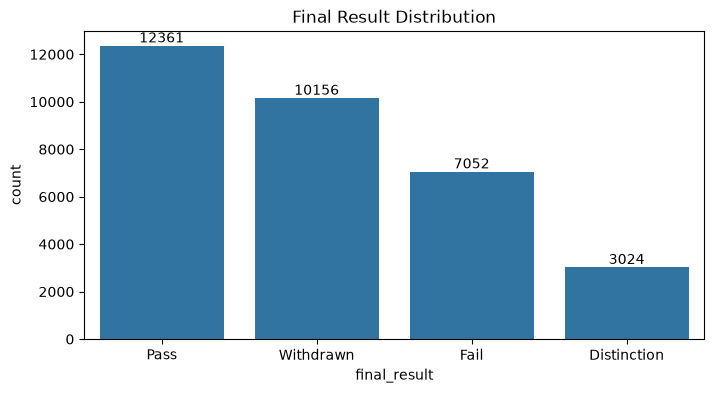

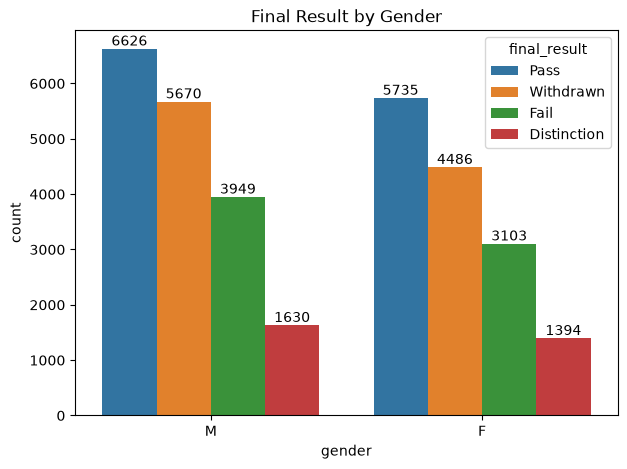

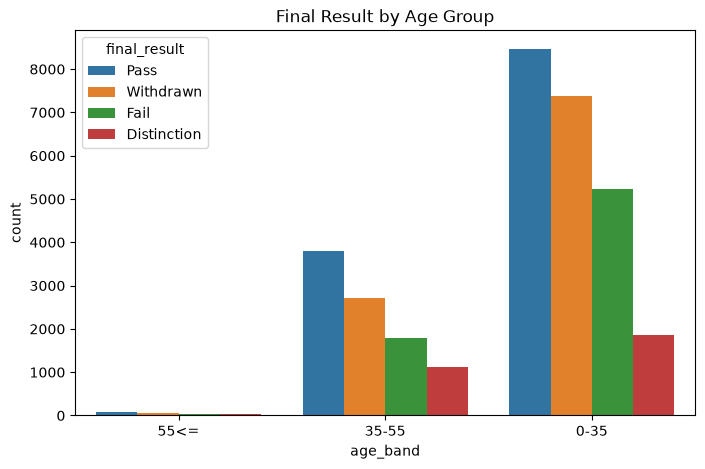

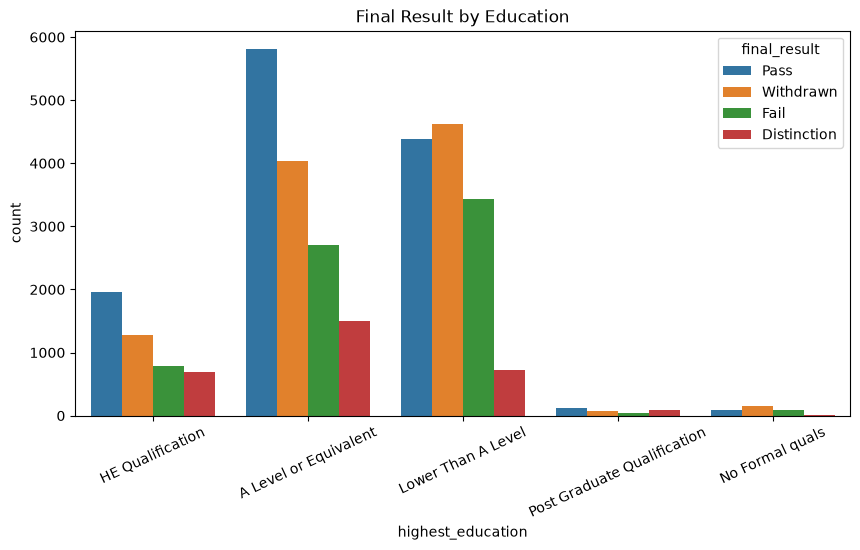

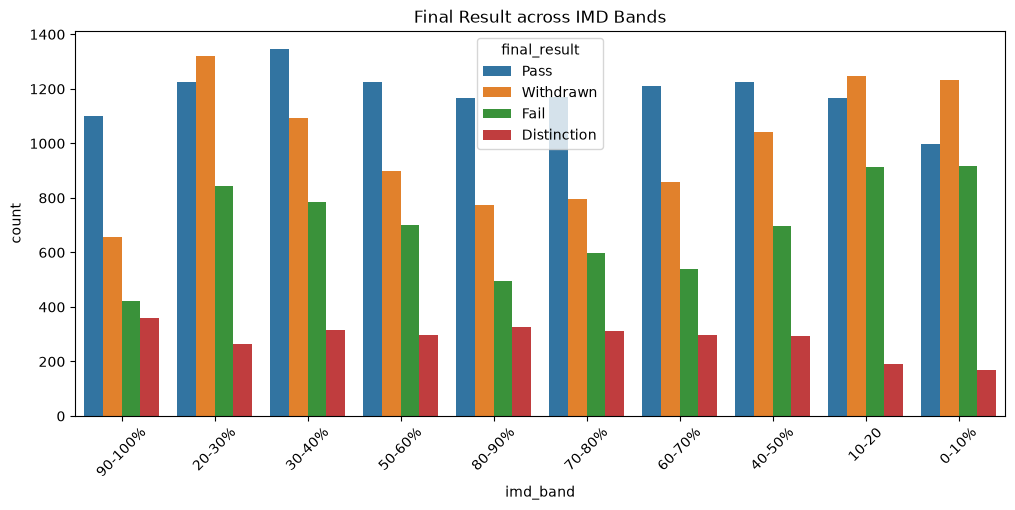

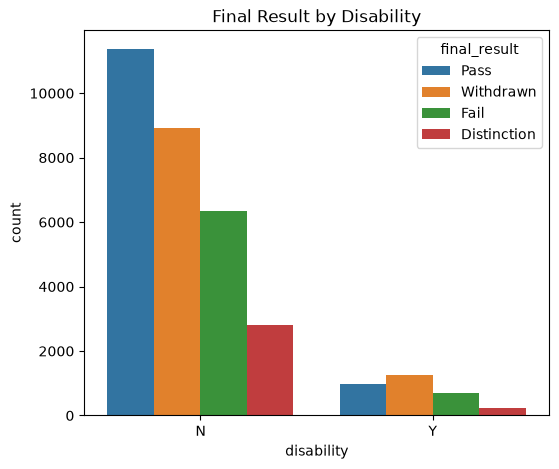

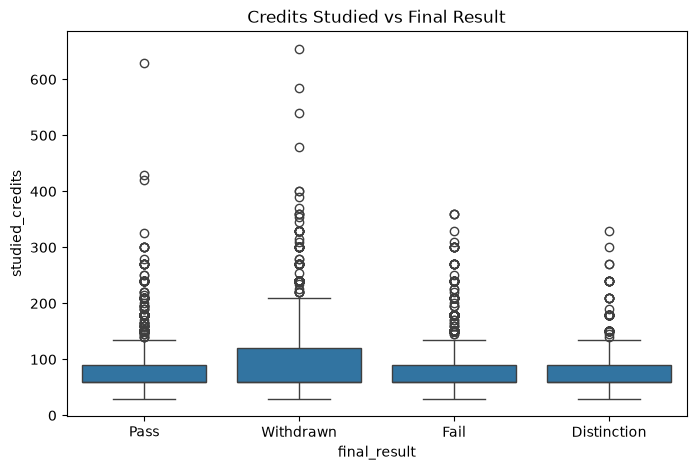

In [22]:
# Student info analysis
print("# Student info analysis")
print(df_students.head())
print('final result counts:')
print(df_students['final_result'].value_counts(dropna=False))
for col in ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability']:
    if col in df_students.columns:
        print(f'--- {col} ---')
        print(df_students[col].value_counts(dropna=False).head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=df_students, x='final_result', order=df_students['final_result'].value_counts().index)
for container in plt.gca().containers:
    plt.bar_label(container)
print("\nFinal Result Percentage")

print(
    round(
        df_students["final_result"]
        .value_counts(normalize=True)*100,
        2
    )
)
plt.title('Final Result Distribution')
plt.show()

#Gender Countplot: Added By Kiran
plt.figure(figsize=(7,5))

sns.countplot(
    data=df_students,
    x="gender",
    hue="final_result"
)

plt.title("Final Result by Gender")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.show()

#Age Band Plot: : Added By Kiran
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_students,
    x="age_band",
    hue="final_result"
)

plt.title("Final Result by Age Group")

plt.show()

#Education Countplot-Added By Kiran
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_students,
    x="highest_education",
    hue="final_result"
)

plt.xticks(rotation=25)
plt.title("Final Result by Education")
plt.show()

#IMD Band:Index of Multiple Deprivation-It represents Socioeconomic status.
plt.figure(figsize=(12,5))

sns.countplot(
    data=df_students,
    x="imd_band",
    hue="final_result"
)

plt.xticks(rotation=45)
plt.title("Final Result across IMD Bands")
plt.show()

#Disability
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_students,
    x="disability",
    hue="final_result"
)

plt.title("Final Result by Disability")
plt.show()

#Studied Credits Histogram
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_students,
    x="final_result",
    y="studied_credits"
)

plt.title("Credits Studied vs Final Result")

plt.show()

# Student Info Analysis Conclusion:
The studentInfo.csv dataset contains demographic, educational, and academic information for 32,593 student-course enrollments. It includes variables such as gender, age, education level, socioeconomic status (IMD band), disability, previous attempts, studied credits, and the final course outcome. These variables form the foundation for predicting student success and dropout.

## Final Result Distribution
Pass         37.93%
Withdrawn    31.16%
Fail         21.64%
Distinction   9.28%
### Conclusion
Pass is the most common outcome (37.93%).
A substantial proportion (31.16%) of students withdrew before completing the course.
Around 21.64% failed, while only 9.28% achieved a distinction.

Nearly one-third of students withdrew.

## Gender Analysis
Male:   17,875
Female: 14,718
### Conclusion
Male students slightly outnumber female students.
The distribution of Pass, Fail, Withdrawn, and Distinction appears broadly similar across genders.

Gender alone does not appear to strongly differentiate academic outcomes. However, it may still contribute as one of several features in the predictive model when combined with other variables.

## Age Band Analysis
0–35 : 22,944
35–55: 9,433
55+  :   216
### Conclusion
Most students belong to the 0–35 years age group.
Very few students are older than 55 years.
The outcome distribution varies across age groups, suggesting that age may influence learning behaviour and course completion.

Age may capture differences in experience, responsibilities, or study habits, making it a potentially useful predictor of student dropout.

## Highest Education
A Level                14,045
Lower Than A Level     13,158
HE Qualification        4,730
### Conclusion
Most students entered the courses with either A Level or Equivalent or Lower Than A Level qualifications, while relatively few had higher education or postgraduate qualifications.

The distribution of final results suggests that educational background may influence dropout.

Students entering with stronger educational backgrounds may be better prepared for course requirements, making education level an informative feature for dropout prediction.

## IMD Band (Socioeconomic Status)
Missing: 1111
### Conclusion
Students are fairly evenly distributed across socioeconomic groups, with only 3.4% missing values.

The variation in final results across IMD bands suggests that socioeconomic status may influence academic outcomes and student dropout.
Socioeconomic status has been shown in educational research to affect access to resources and learning opportunities. It is therefore a valuable feature to retain for predictive modelling.

## Previous Attempts
0 previous attempts : 28,421
### Conclusion
Most students are attempting the course for the first time, while relatively few have repeated the course.

Students with previous unsuccessful attempts may exhibit different learning behaviours and academic outcomes compared with first-time learners. Previous attempts could therefore improve the predictive performance of the model.

## Studied Credits
60 credits : 16,751
### Conclusion
The majority of students are enrolled in 60-credit modules, while larger credit loads are much less common.
The boxplot indicates that students with different final outcomes may have different credit loads, suggesting that course workload could influence academic performance and dropout.

Higher study loads may increase academic pressure, whereas lighter loads may allow students to balance their studies more effectively. Studied credits may therefore contribute to dropout prediction.

## Disability
No disability : 29,429
Disability    : 3,164
### Conclusion
Most students reported no disability, with approximately 10% indicating a disability.

The countplot shows differences in the distribution of final results between the two groups, although the imbalance in group sizes should be considered when interpreting the results.

Disability status may influence the support required by students and could contribute additional predictive information when combined with other demographic and behavioural variables.

### Overall Student Information Analysis:
The student information analysis shows that the dataset contains a diverse population of learners with varying demographic, educational, and socioeconomic backgrounds. Approximately one-third of students withdrew from their courses, highlighting the importance of predicting dropout. Variables such as age, education level, socioeconomic status, previous attempts, studied credits, and disability exhibit meaningful variation across student outcomes and may serve as useful predictors in the machine learning model. While demographic variables alone may not fully explain academic success, combining them with behavioural data such as assessment performance and VLE engagement is expected to improve dropout prediction.

# Bivariate Analysis

For a predictive modeling project, we should analyze each feature against the target variable (final_result).

Instead of:

Gender distribution
Age distribution
Education distribution

We should ask:

Does gender influence outcomes?
Does age influence outcomes?
Does education influence outcomes?
Does socioeconomic status influence outcomes?
Does disability status influence outcomes?

This is called bivariate analysis, and it's much more valuable than univariate analysis because it starts uncovering relationships that the machine learning model may later learn.

## Gender vs Final Result

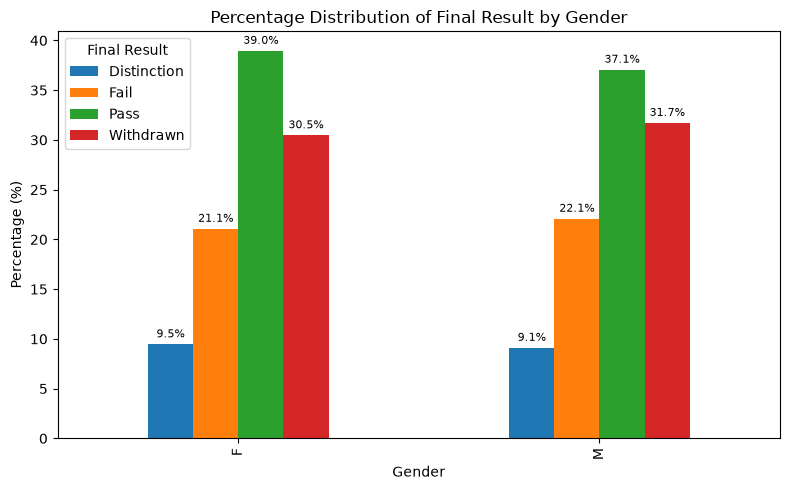

In [23]:
# Gender vs Final Result
# ==========================================================
gender_pct = pd.crosstab(
    df_students['gender'],
    df_students['final_result'],
    normalize='index'
) * 100

# Create grouped bar chart
ax = gender_pct.plot(
    kind='bar',
    figsize=(8,5)
)

# ===== Added: Display percentage labels on bars =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",      # Show one decimal place with %
        fontsize=8,
        padding=3
    )

# Formatting
plt.ylabel("Percentage (%)")
plt.xlabel("Gender")
plt.title("Percentage Distribution of Final Result by Gender")
plt.legend(title="Final Result")
plt.tight_layout()

plt.show()

2. Age vs Final Result

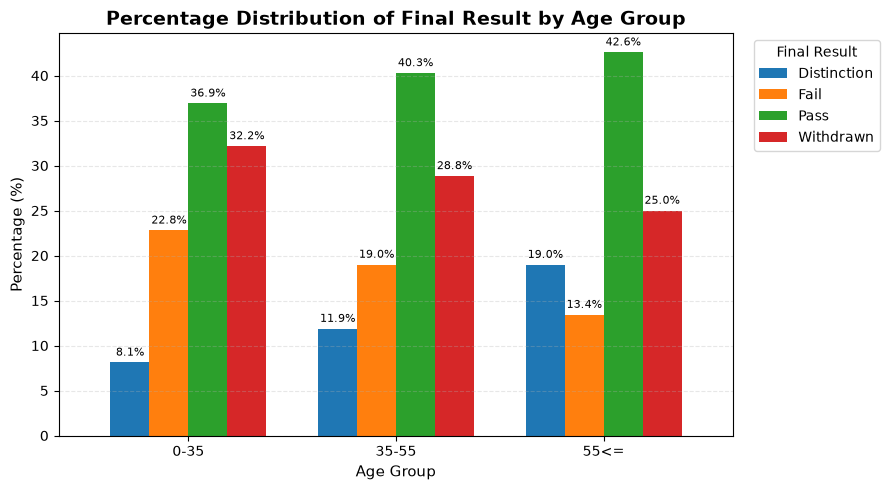

In [24]:
# Percentage of Final Result within each Age Group

age_pct = pd.crosstab(
    df_students['age_band'],
    df_students['final_result'],
    normalize='index'
) * 100

# Create grouped bar chart
ax = age_pct.plot(
    kind='bar',
    figsize=(9,5),
    width=0.75
)

# ===== Added: Display percentage labels =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8,
        padding=3
    )

# Formatting
plt.title(
    "Percentage Distribution of Final Result by Age Group",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Age Group", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title="Final Result",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

3. Education vs Final Result

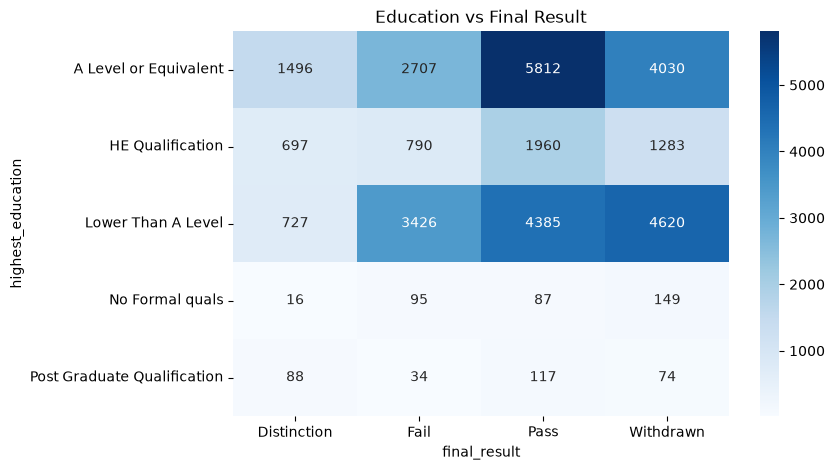

In [25]:
education = pd.crosstab( 
    df_students['highest_education'], 
    df_students['final_result'] 
    )
plt.figure(figsize=(8,5))
sns.heatmap( 
    education, 
    annot=True, 
    fmt="d", 
    cmap="Blues" 
    )
plt.title("Education vs Final Result") 
plt.show()


4. IMD Band vs Final Result

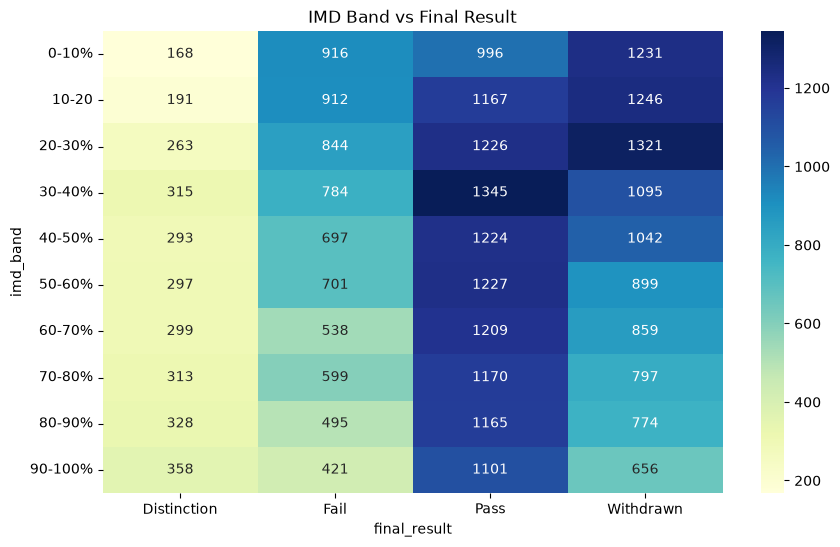

In [26]:
imd = pd.crosstab(
    df_students['imd_band'],
    df_students['final_result']
)

plt.figure(figsize=(10,6))

sns.heatmap(
    imd,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("IMD Band vs Final Result")
plt.show()

5. Disability vs Final Result

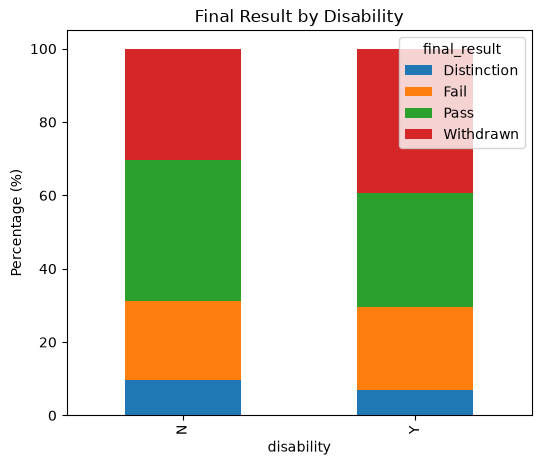

In [27]:
disability_pct = pd.crosstab(
    df_students['disability'],
    df_students['final_result'],
    normalize='index'
) * 100

disability_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5)
)

plt.title("Final Result by Disability")
plt.ylabel("Percentage (%)")
plt.show()

6. Previous Attempts vs Final Result

num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64


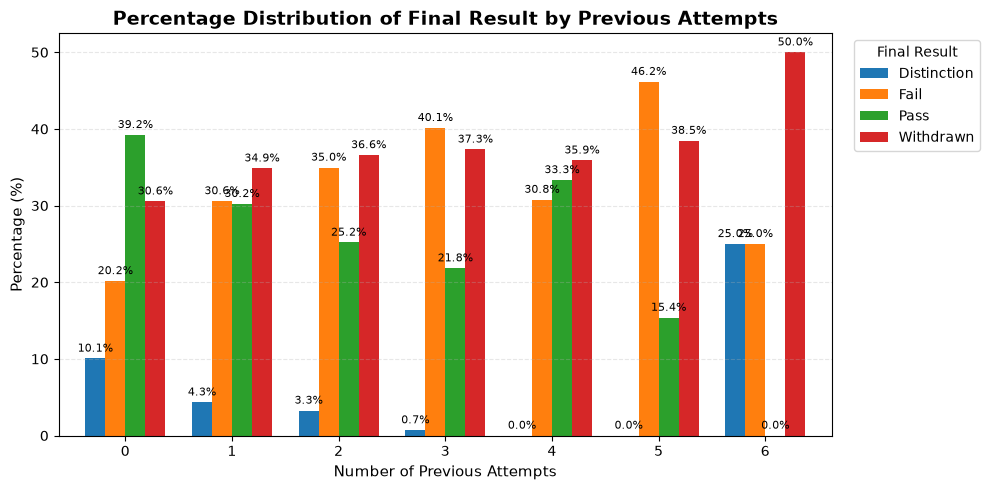

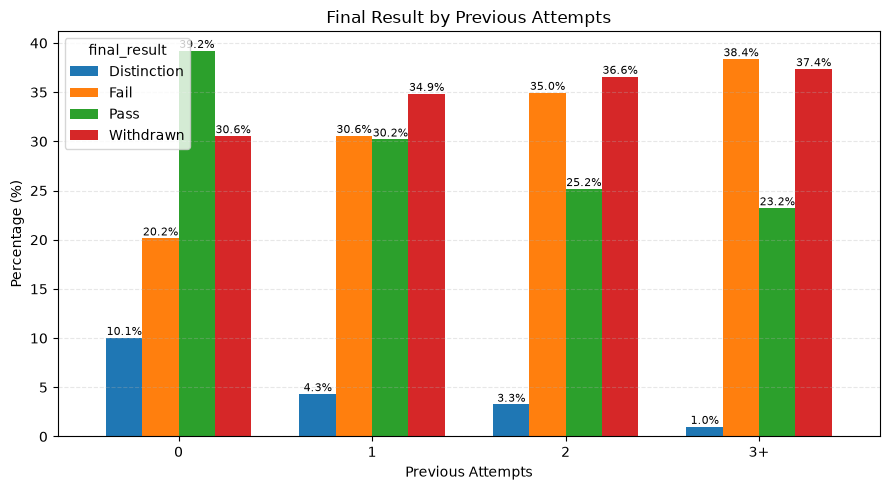

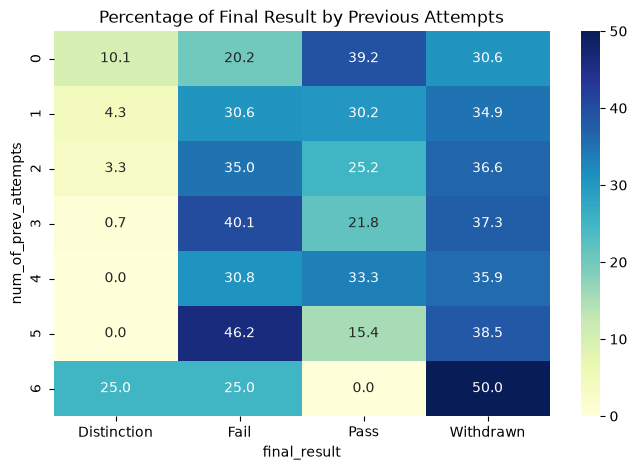

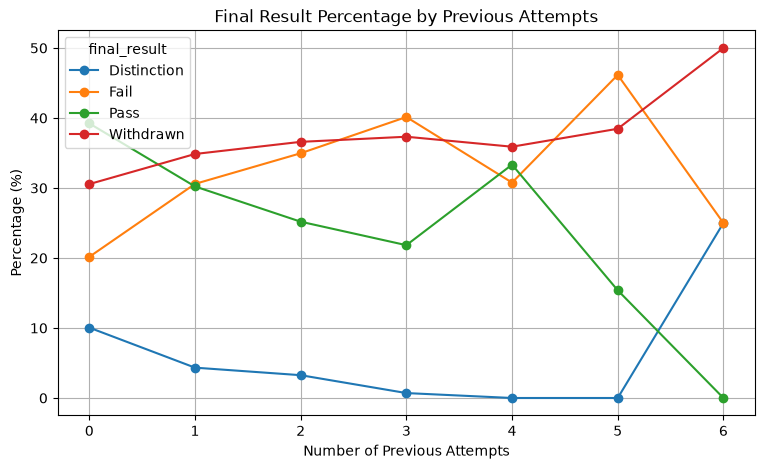

In [28]:
print(df_students['num_of_prev_attempts'].value_counts().sort_index())
# Percentage Distribution of Final Result by Previous Attempts

attempts_pct = pd.crosstab(
    df_students['num_of_prev_attempts'],
    df_students['final_result'],
    normalize='index'
) * 100

# Create grouped bar chart
ax = attempts_pct.plot(
    kind='bar',
    figsize=(10,5),
    width=0.75
)

# ===== Added: Display percentage labels =====
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8,
        padding=3
    )

# Formatting
plt.title(
    "Percentage Distribution of Final Result by Previous Attempts",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Number of Previous Attempts", fontsize=11)
plt.ylabel("Percentage (%)", fontsize=11)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title="Final Result",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

#Grouped categories
# Create grouped previous attempts
df_students["prev_attempt_group"] = (
    df_students["num_of_prev_attempts"]
    .replace({3: "3+", 4: "3+", 5: "3+", 6: "3+"})
    .astype(str)
)

attempt_pct = pd.crosstab(
    df_students["prev_attempt_group"],
    df_students["final_result"],
    normalize="index"
) * 100

ax = attempt_pct.plot(
    kind="bar",
    figsize=(9,5),
    width=0.75
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        fontsize=8
    )

plt.title("Final Result by Previous Attempts")
plt.xlabel("Previous Attempts")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()
#Heatmap
attempt = pd.crosstab(
    df_students["num_of_prev_attempts"],
    df_students["final_result"],
    normalize="index"
) * 100

plt.figure(figsize=(8,5))

sns.heatmap(
    attempt,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Percentage of Final Result by Previous Attempts")
plt.show()

#Line Chart
attempt_pct = pd.crosstab(
    df_students["num_of_prev_attempts"],
    df_students["final_result"],
    normalize="index"
) * 100

attempt_pct.plot(
    marker="o",
    figsize=(9,5)
)

plt.ylabel("Percentage (%)")
plt.xlabel("Number of Previous Attempts")
plt.title("Final Result Percentage by Previous Attempts")
plt.grid(True)
plt.show()

7. Credits vs Final Result

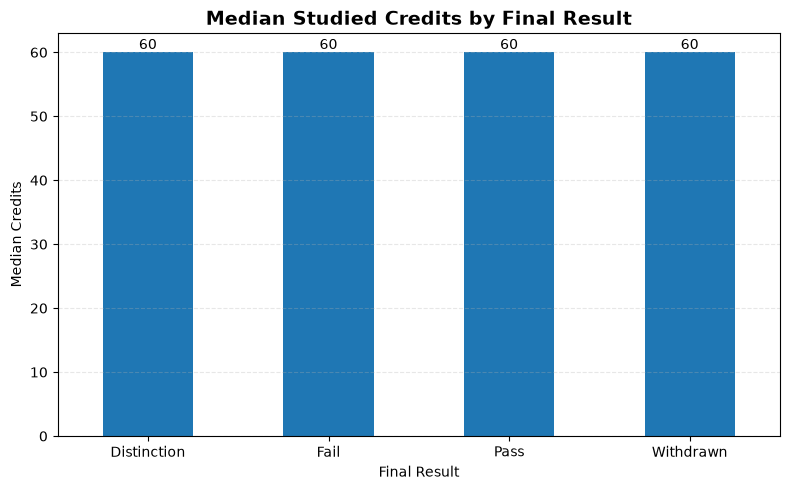

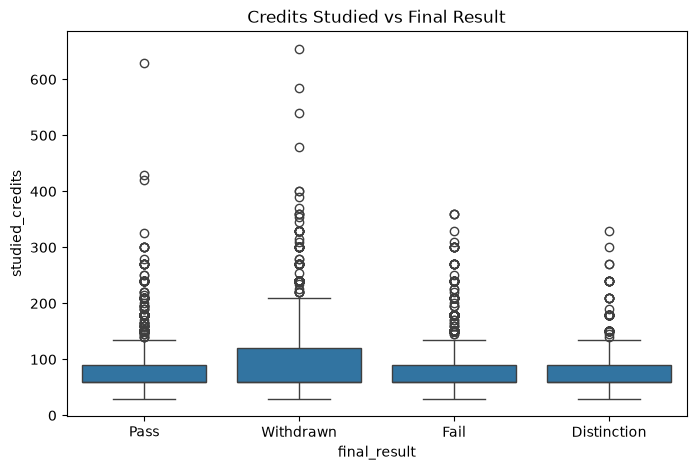

In [29]:

#Median Chart
median_credit = (
    df_students
    .groupby("final_result")["studied_credits"]
    .median()
)

ax = median_credit.plot(
    kind="bar",
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        fontsize=10
    )

plt.title("Median Studied Credits by Final Result", fontsize=14, weight="bold")
plt.xlabel("Final Result")
plt.ylabel("Median Credits")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.show()

#Box plot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_students,
    x='final_result',
    y='studied_credits'
)

plt.title("Credits Studied vs Final Result")

plt.show()

### Observation

• The median number of studied credits is similar across all final result categories.

• Students who withdrew exhibit the greatest variability in studied credits, as indicated by the wider box and longer whiskers.

• All categories contain several high-credit outliers, suggesting that a small number of students enrolled in unusually large credit loads.

• Since the distributions overlap considerably, studied credits alone do not appear to strongly differentiate student outcomes.

### Fairness Observation

The StudentInfo dataset contains sensitive demographic attributes such as gender, age, disability status, and socioeconomic status (IMD Band). These variables are important not only for predicting dropout but also for evaluating whether the machine learning model treats different student groups fairly.

In later stages of the project, fairness metrics will be evaluated to ensure that predictions are not biased toward any demographic group.

### Part 6 – Student Assessment Analysis
In OULAD (Open University Learning Analytics Dataset), is_banked indicates whether the student carried forward (banked) the result of an assessment from a previous presentation of the same module.

Think of it like this:

Scenario 1: Not Banked (is_banked = 0) ✅

A student takes a course and completes a TMA.

They receive:

Score = 82
is_banked = 0

This means:

The student completed this assessment during the current course presentation, and this is their actual score.

Scenario 2: Banked (is_banked = 1)

Suppose a student:

Completed some assignments in 2023
Didn't finish the course and withdrew

The next year, they enroll in the same module again.

Instead of asking them to repeat those completed assignments, the university may carry forward (or bank) the previous assessment scores.

For example:

Year	Assignment Score
2023	78
2024	78 (reused)

Here:

score = 78
is_banked = 1

The score wasn't earned again; it was transferred from an earlier attempt.

Simple definition for your report

is_banked indicates whether an assessment score was carried forward from a previous attempt at the same course (1) or earned during the current course presentation (0).

Why is this important?

Banked assessments may behave differently because:

The student did not retake the assessment.
The score reflects previous work rather than current performance.
It can influence analyses of student progress.

For example, you could investigate whether students with banked assessments have different final outcomes than students without them.

# Student assessment analysis
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22          0   70.0
2           1752       31604              17          0   72.0
3           1752       32885              26          0   69.0
4           1752       38053              19          0   79.0
       id_assessment    id_student  date_submitted      is_banked  \
count  173912.000000  1.739120e+05   173912.000000  173912.000000   
mean    26553.803556  7.051507e+05      116.032942       0.010977   
std      8829.784254  5.523952e+05       71.484148       0.104194   
min      1752.000000  6.516000e+03      -11.000000       0.000000   
25%     15022.000000  5.044290e+05       51.000000       0.000000   
50%     25359.000000  5.852080e+05      116.000000       0.000000   
75%     34883.000000  6.344980e+05      173.000000       0.000000   
max     37443.000000  2.698588e+06      

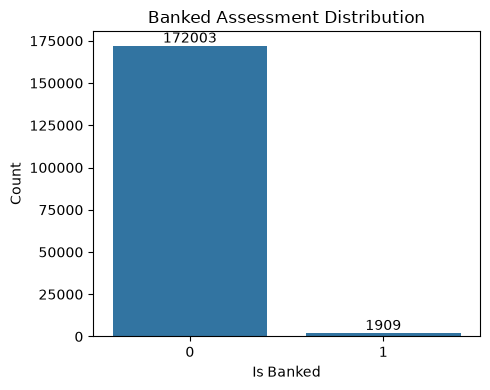

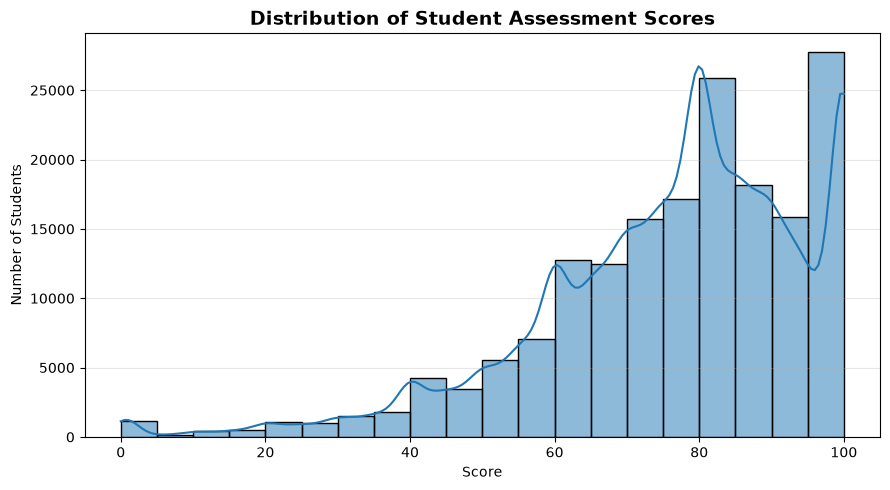

scores by assessment type:
                   count       mean        std  min   25%   50%   75%    max
assessment_type                                                             
CMA              70527.0  81.027053  17.836026  0.0  72.0  82.0  98.0  100.0
Exam              4959.0  65.572898  20.579186  0.0  51.0  67.0  82.0  100.0
TMA              98253.0  72.563392  18.432823  0.0  63.0  76.0  86.0  100.0


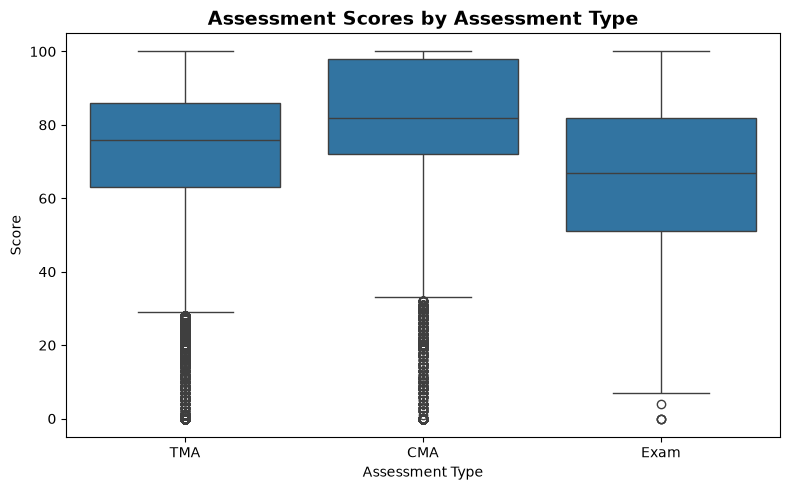

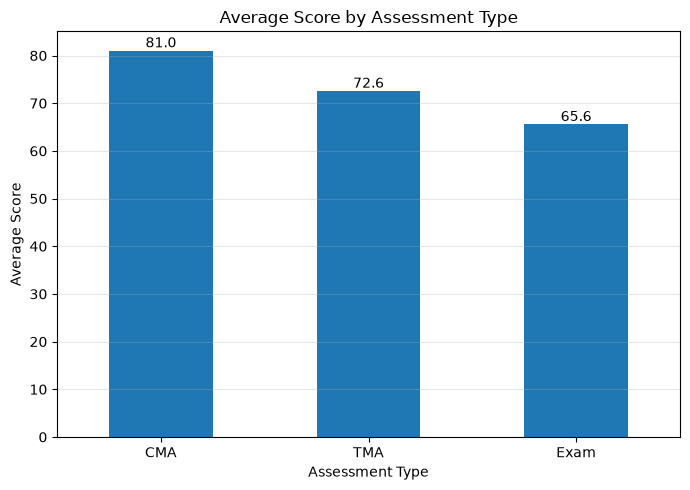

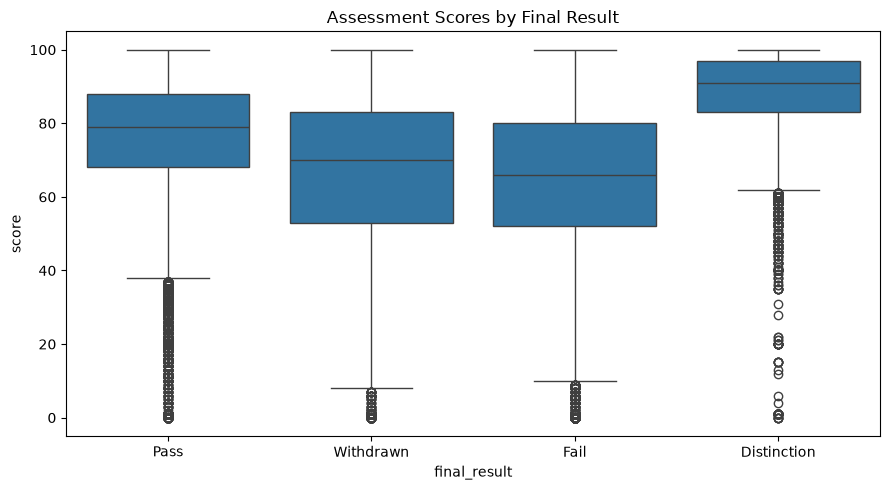

In [30]:
# Student assessment analysis
# Dataset Preview
print("# Student assessment analysis")
print(df_studentAssessments.head())
#Dataset Summary
print(df_studentAssessments.describe(include='all'))
#Missing Scores
print('missing scores:', df_studentAssessments['score'].isna().sum())
missing = df_studentAssessments['score'].isna().sum() #Added By Kiran
print(f"Missing Scores: {missing}") #Added By Kiran
print(f"Missing Percentage: {(missing/len(df_studentAssessments))*100:.2f}%") #Added By Kiran

print('banked counts:')
print(df_studentAssessments['is_banked'].value_counts(dropna=False))
#Visualization
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=df_studentAssessments,
    x='is_banked'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Banked Assessment Distribution")
plt.xlabel("Is Banked")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Score Distribution
plt.figure(figsize=(9,5))

sns.histplot(
    df_studentAssessments['score'],
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Student Assessment Scores",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Merge with Assessment Table

merged_scores = df_studentAssessments.merge(df_assessments, on='id_assessment', how='left')
print('scores by assessment type:')
print(merged_scores.groupby('assessment_type')['score'].describe())

#Visualization
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=merged_scores,
    x='assessment_type',
    y='score'
)

plt.title(
    "Assessment Scores by Assessment Type",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Assessment Type")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

# Average score by assessment type
avg_score = (
    merged_scores
    .groupby('assessment_type')['score']
    .mean()
    .sort_values(ascending=False)
)

ax = avg_score.plot(
    kind='bar',
    figsize=(7,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.title("Average Score by Assessment Type")
plt.xlabel("Assessment Type")
plt.ylabel("Average Score")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Comparing scores with the final result
score_result = merged_scores.merge(
    df_students[
        ['id_student',
         'code_module',
         'code_presentation',
         'final_result']
    ],
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

plt.figure(figsize=(9,5))

sns.boxplot(
    data=score_result,
    x='final_result',
    y='score'
)

plt.title("Assessment Scores by Final Result")
plt.tight_layout()
plt.show()

### Registration Anslysis

# Registration analysis
  code_module code_presentation  id_student  date_registration  \
0         AAA             2013J       11391             -159.0   
1         AAA             2013J       28400              -53.0   
2         AAA             2013J       30268              -92.0   
3         AAA             2013J       31604              -52.0   
4         AAA             2013J       32885             -176.0   

   date_unregistration  
0                  NaN  
1                  NaN  
2                 12.0  
3                  NaN  
4                  NaN  
       code_module code_presentation    id_student  date_registration  \
count        32593             32593  3.259300e+04       32548.000000   
unique           7                 4           NaN                NaN   
top            BBB             2014J           NaN                NaN   
freq          7909             11260           NaN                NaN   
mean           NaN               NaN  7.066877e+05         -69.4

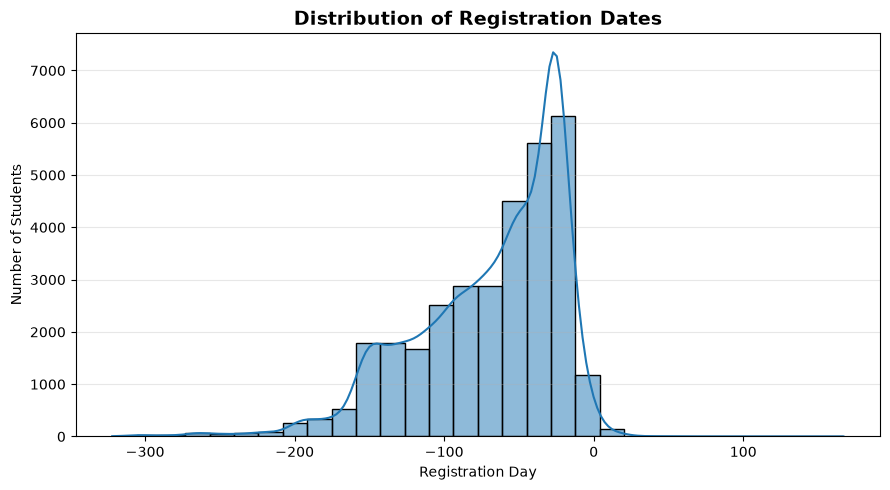

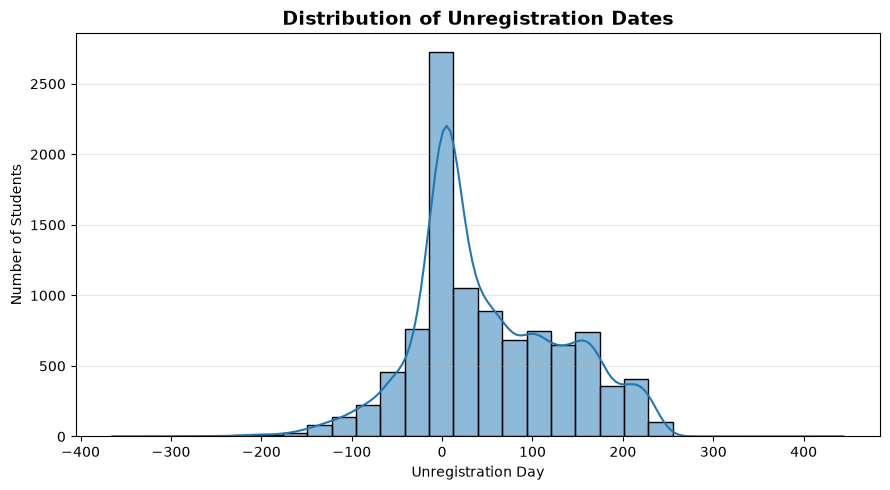

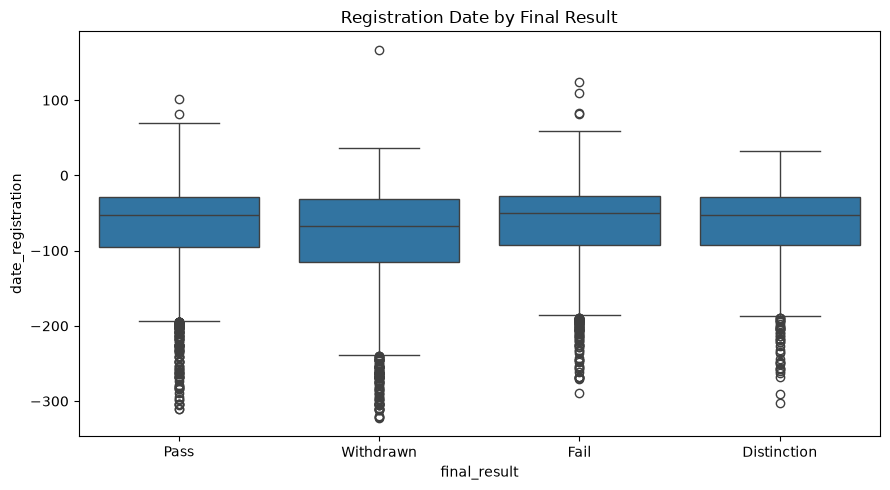

date_unregistration
True     22521
False    10072
Name: count, dtype: int64


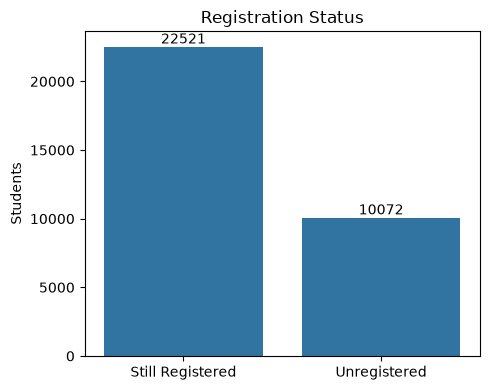

Total Students : 32593
Unregistered : 10072
Percentage : 30.90%


In [31]:
# Registration analysis
#Dataset Preview
print("# Registration analysis")
print(df_studentRegistration.head())
# Summary Statistics
print(df_studentRegistration.describe(include='all'))
# Missing Unregistration Dates
print('missing unregistration dates:', df_studentRegistration['date_unregistration'].isna().sum())

missing = df_studentRegistration['date_unregistration'].isna().sum()

print(f"Missing Unregistration Dates: {missing}")
print(f"Missing Percentage: {(missing/len(df_studentRegistration))*100:.2f}%")

# Registration Date Histogram
plt.figure(figsize=(9,5))

sns.histplot(
    df_studentRegistration['date_registration'],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Registration Dates",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Registration Day")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Unregistration Histogram
if 'date_unregistration' in df_studentRegistration.columns:
    valid_unreg = df_studentRegistration[df_studentRegistration['date_unregistration'].notna()]
    plt.figure(figsize=(9,5))

sns.histplot(
    valid_unreg['date_unregistration'],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Unregistration Dates",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Unregistration Day")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Registration vs Final Result
registration_result = df_studentRegistration.merge(
    df_students[
        [
            'id_student',
            'code_module',
            'code_presentation',
            'final_result'
        ]
    ],
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

#Compare registration Dates
plt.figure(figsize=(9,5))

sns.boxplot(
    data=registration_result,
    x='final_result',
    y='date_registration'
)

plt.title("Registration Date by Final Result")
plt.tight_layout()
plt.show()

#Registration vs Unregistration
print(df_studentRegistration['date_unregistration'].isna().value_counts())

status = df_studentRegistration['date_unregistration'].isna()

status = status.map({
    True: 'Still Registered',
    False: 'Unregistered'
})

plt.figure(figsize=(5,4))

ax = sns.countplot(
    x=status
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Registration Status")

plt.xlabel("")
plt.ylabel("Students")
plt.tight_layout()
plt.show()

# How many students actually unregistered
total = len(df_studentRegistration)

unregistered = (
    df_studentRegistration
    ['date_unregistration']
    .notna()
    .sum()
)

print(f"Total Students : {total}")
print(f"Unregistered : {unregistered}")
print(f"Percentage : {(unregistered/total)*100:.2f}%")



### Observation

• Most students have a missing `date_unregistration`, indicating they remained enrolled or completed the course.

• Registration dates are distributed across the presentation period, with some students registering much earlier than others.

• The distribution of unregistration dates helps identify when students are most likely to leave the course.

• Comparing registration dates across final result categories can reveal whether early registration is associated with better academic outcomes.

### VLE (Virtual Learning Environment)
VLE (Virtual Learning Environment) interactions measure student engagement, and engagement is usually one of the strongest predictors of student dropout.

# VLE analysis
   id_site code_module code_presentation activity_type  week_from  week_to
0   546943         AAA             2013J      resource        NaN      NaN
1   546712         AAA             2013J     oucontent        NaN      NaN
2   546998         AAA             2013J      resource        NaN      NaN
3   546888         AAA             2013J           url        NaN      NaN
4   547035         AAA             2013J      resource        NaN      NaN
activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64
week_from missing: 5243
week_to mis

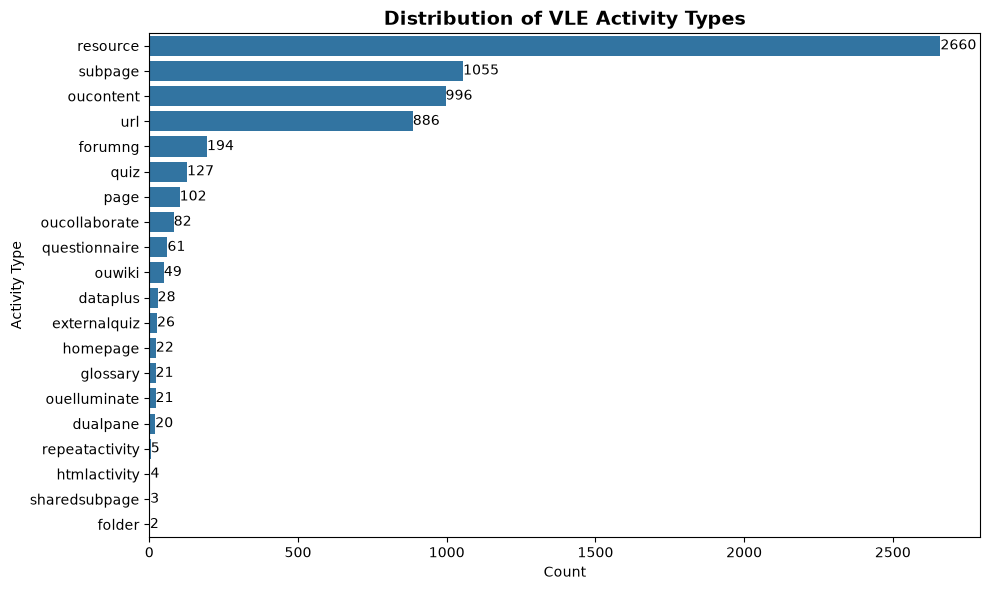

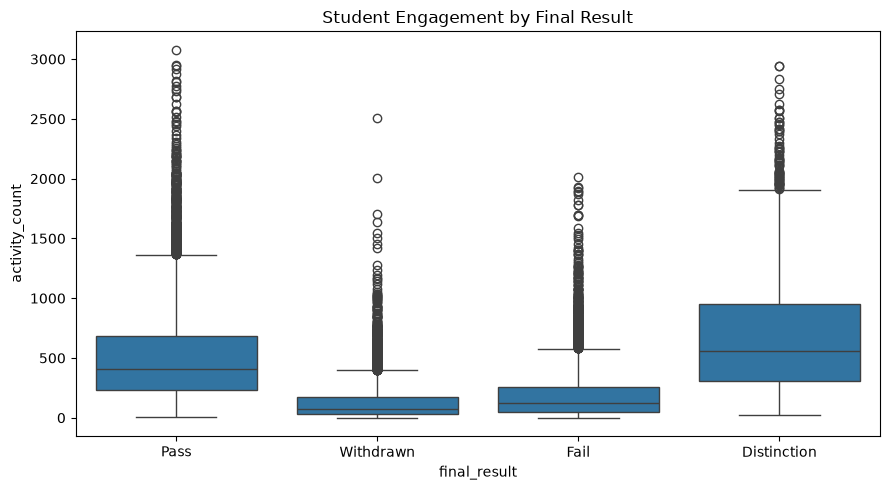

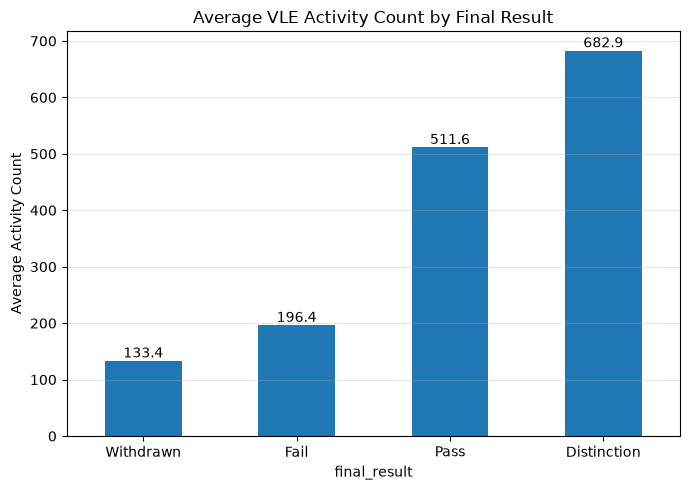

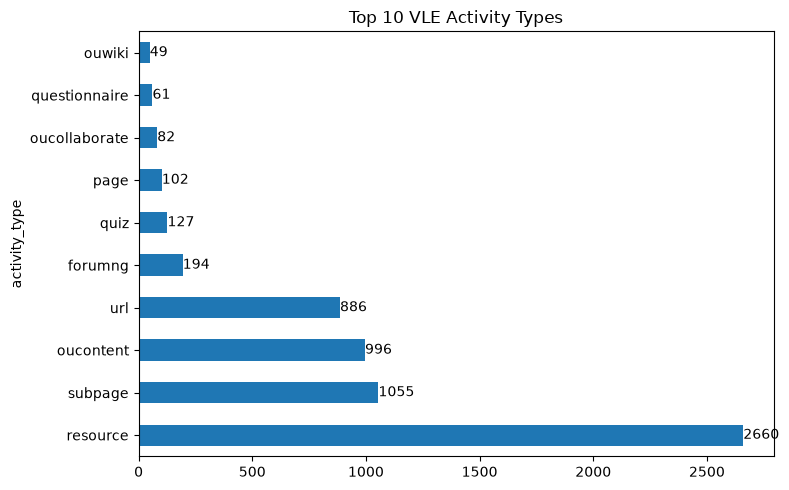

In [35]:
# VLE analysis
# VLE Dataset Preview
print("# VLE analysis")
print(df_vle.head())
# Activity Type Counts
print(df_vle['activity_type'].value_counts(dropna=False).head(20))
# Missing Values
print('week_from missing:', df_vle['week_from'].isna().sum())
print('week_to missing:', df_vle['week_to'].isna().sum())

for col in ['week_from', 'week_to']:
    missing = df_vle[col].isna().sum()

    print(f"{col} Missing: {missing}")
    print(f"{col} Missing Percentage: {(missing/len(df_vle))*100:.2f}%")

# Activity Type Count Plot
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_vle,
    y='activity_type',
    order=df_vle['activity_type'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(
        container
    )

plt.title(
    "Distribution of VLE Activity Types",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Count")
plt.ylabel("Activity Type")

plt.tight_layout()

plt.show()

# Create engagement dataframe
engagement = (
    df_studentVle
    .groupby(
        [
            'id_student',
            'code_module',
            'code_presentation'
        ]
    )
    .agg(
        activity_count=('id_site', 'count'),
        total_clicks=('sum_click', 'sum'),
        active_days=('date', 'nunique'),
        unique_resources=('id_site', 'nunique')
    )
    .reset_index()
)
# Engagement vs Final Result
engagement_result = engagement.merge(
    df_students[
        [
            'id_student',
            'code_module',
            'code_presentation',
            'final_result'
        ]
    ],
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

# Compare engagement
plt.figure(figsize=(9,5))

sns.boxplot(
    data=engagement_result,
    x='final_result',
    y='activity_count'
)

plt.title("Student Engagement by Final Result")
plt.tight_layout()
plt.show()

# Average engagemen
avg_engagement = (
    engagement_result
    .groupby('final_result')['activity_count']
    .mean()
    .sort_values()
)

ax = avg_engagement.plot(
    kind='bar',
    figsize=(7,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.title("Average VLE Activity Count by Final Result")
plt.ylabel("Average Activity Count")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Top activity types
top10 = (
    df_vle['activity_type']
    .value_counts()
    .head(10)
)

ax = top10.plot(
    kind='barh',
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 VLE Activity Types")
plt.tight_layout()
plt.show()

### Cross-dataset analysis
It starts answering the project's main question: "How do assessment scores relate to student outcomes?"

# Cross-dataset analysis
merged shape: (173912, 20)
imd_band                7697
date                    2865
score                    173
id_assessment              0
is_banked                  0
date_submitted             0
id_student                 0
code_presentation          0
assessment_type            0
weight                     0
gender                     0
code_module                0
region                     0
highest_education          0
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
prev_attempt_group         0
dtype: int64
                      Missing Count  Missing %
imd_band                       7697       4.43
date                           2865       1.65
score                           173       0.10
id_assessment                     0       0.00
is_banked                         0       0.00
date_submitted                    0       0.00
id_student                

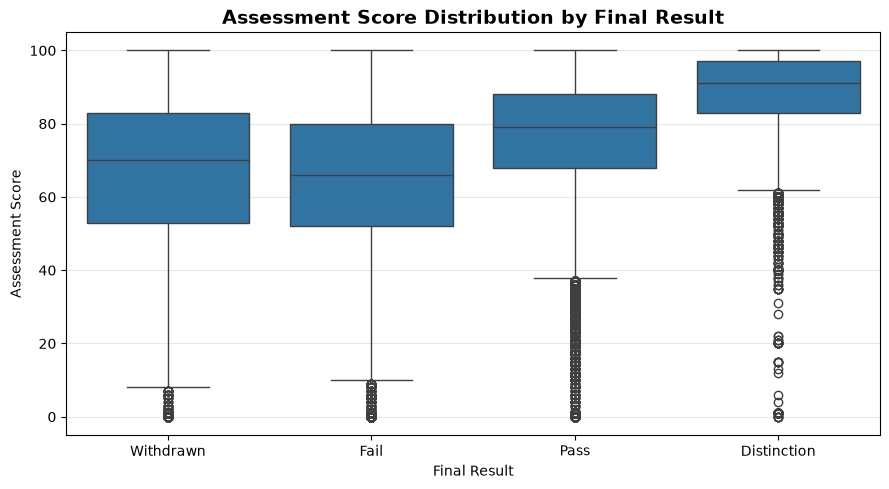

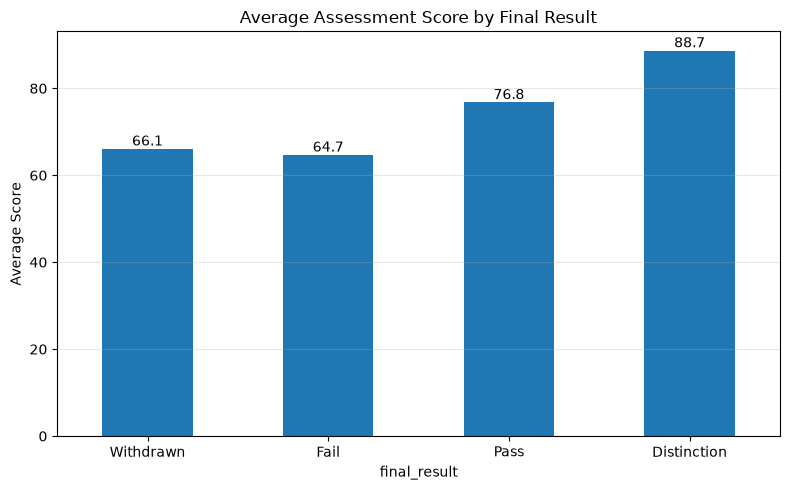

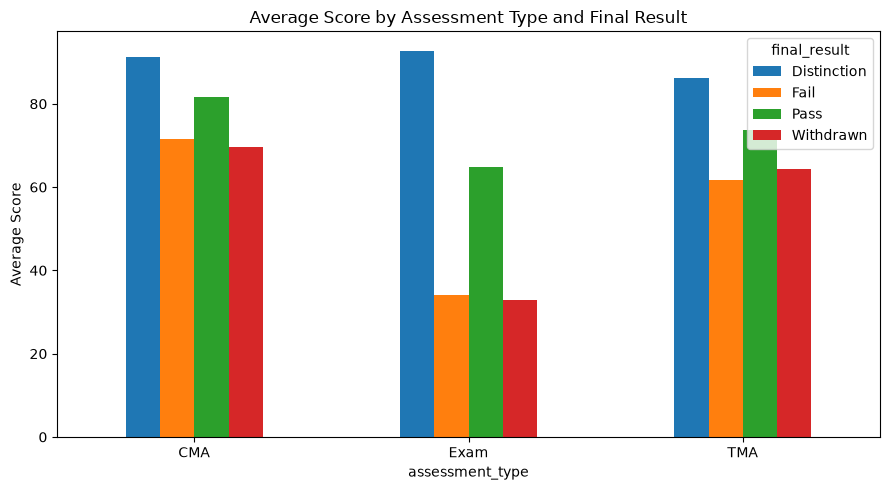

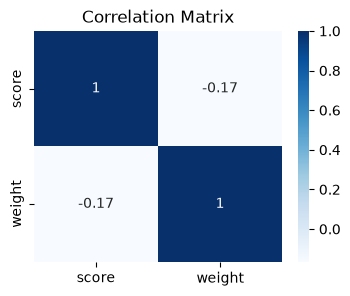

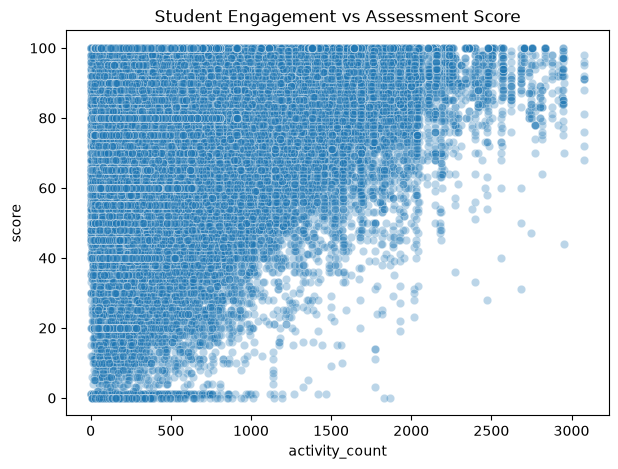

In [ ]:
# Cross-dataset analysis
print("# Cross-dataset analysis")
# Merge the Datasets
merged = df_studentAssessments.merge(df_assessments, on='id_assessment', how='left')
merged = merged.merge(df_students, on=['code_module', 'code_presentation', 'id_student'], how='left')

# Check Shape
print('merged shape:', merged.shape)

# Missing Values
print(merged.isna().sum().sort_values(ascending=False).head(20))

missing = (
    merged
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (
    merged
    .isna()
    .mean()*100
).sort_values(ascending=False)

print(pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
}).head(20))

# Score Summary
result_score = merged.groupby('final_result')['score'].agg(['count', 'mean', 'median', 'std']).reset_index()
print(result_score)

# Score Distribution
plt.figure(figsize=(9,5))

sns.boxplot(
    data=merged,
    x='final_result',
    y='score',
    order=['Withdrawn','Fail','Pass','Distinction']
)

plt.title(
    "Assessment Score Distribution by Final Result",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Final Result")
plt.ylabel("Assessment Score")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Bar Chart
avg_score = (
    merged
    .groupby('final_result')['score']
    .mean()
    .reindex(
        ['Withdrawn','Fail','Pass','Distinction']
    )
)

ax = avg_score.plot(
    kind='bar',
    figsize=(8,5)
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f"
    )

plt.title("Average Assessment Score by Final Result")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Compare assessment types
score_type = (
    merged
    .groupby(
        ['assessment_type',
         'final_result']
    )['score']
    .mean()
    .unstack()
)

score_type.plot(
    kind='bar',
    figsize=(9,5)
)

plt.title(
    "Average Score by Assessment Type and Final Result"
)

plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation
corr = merged[
    [
        'score',
        'weight'
    ]
].corr()

plt.figure(figsize=(4,3))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")
plt.show()

# Student Engagement + Score: Merge VLE engagement
engagement_score = merged.merge(
    engagement,
    on=[
        'id_student',
        'code_module',
        'code_presentation'
    ],
    how='left'
)

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=engagement_score,
    x='activity_count',
    y='score',
    alpha=0.3
)

plt.title(
    "Student Engagement vs Assessment Score"
)

plt.show()

### Explore the existing variables and their relationships

### 1. Missing Value Summary (Overall Dataset)

Observation

The merged dataset contains missing values primarily in assessment scores and registration-related fields. These missing values will be handled appropriately during preprocessing.

In [ ]:
print("# Missing Values in Merged Dataset")

missing = pd.DataFrame({
    'Missing Count': merged.isnull().sum(),
    'Missing Percentage': (
        merged.isnull().mean() * 100
    ).round(2)
})

missing = missing[
    missing['Missing Count'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)

print(missing)

# Missing Values in Merged Dataset
          Missing Count  Missing Percentage
imd_band           7697                4.43
date               2865                1.65
score               173                0.10


### 2. Correlation Matrix (Only Numeric Features)

Since this uses existing numeric columns, it belongs in EDA.

Observation

Most numeric variables exhibit weak to moderate correlations. Assessment score and assessment weight show a positive relationship, while registration-related variables exhibit comparatively weaker associations.

In [ ]:
numeric_columns = [
    'score',
    'weight',
    'date',
    'studied_credits',
    'num_of_prev_attempts',
    'date_registration',
    'date_unregistration'
]

corr = merged[numeric_columns].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numeric Features",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.show()

KeyError: "['date_registration', 'date_unregistration'] not in index"

3. Pairplot

Shows relationships among the important numeric variables.

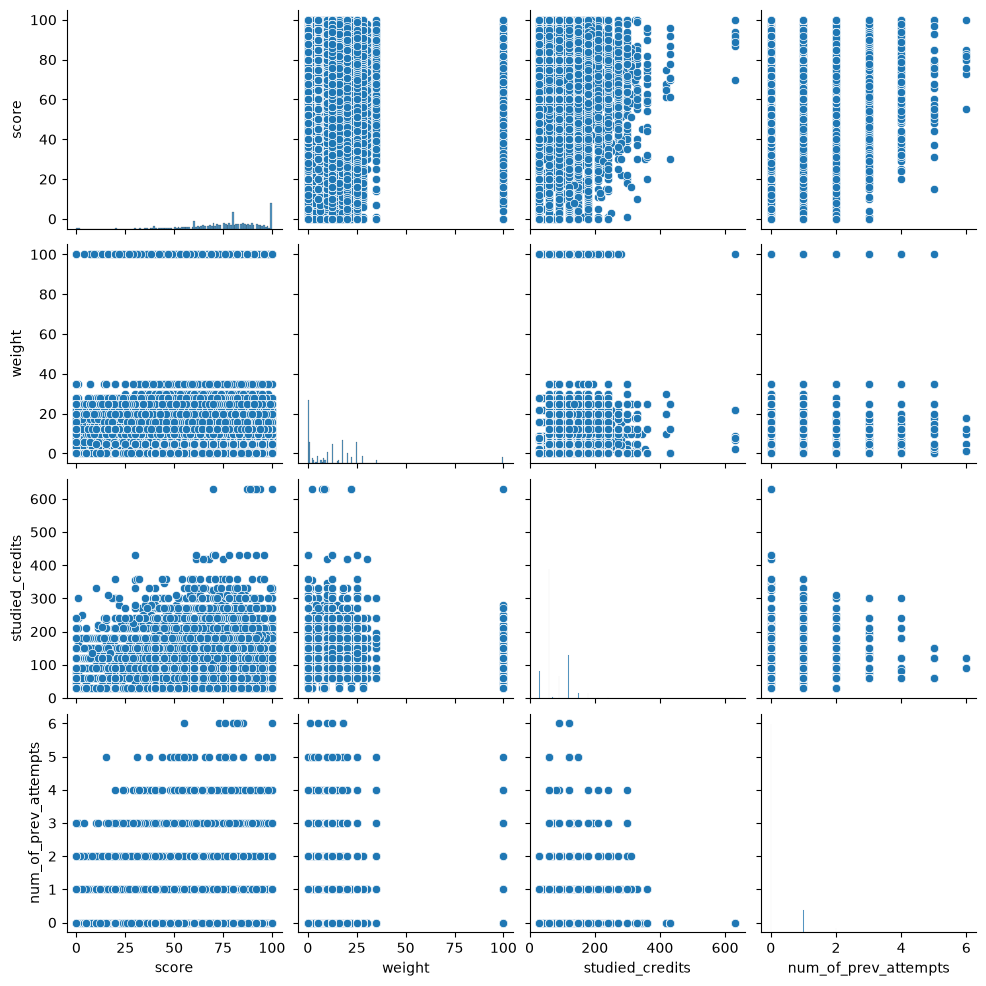

In [ ]:
pairplot_data = merged[
    [
        'score',
        'weight',
        'studied_credits',
        'num_of_prev_attempts'
    ]
].dropna()

sns.pairplot(pairplot_data)

plt.show()

### 4. Module-wise Student Distribution

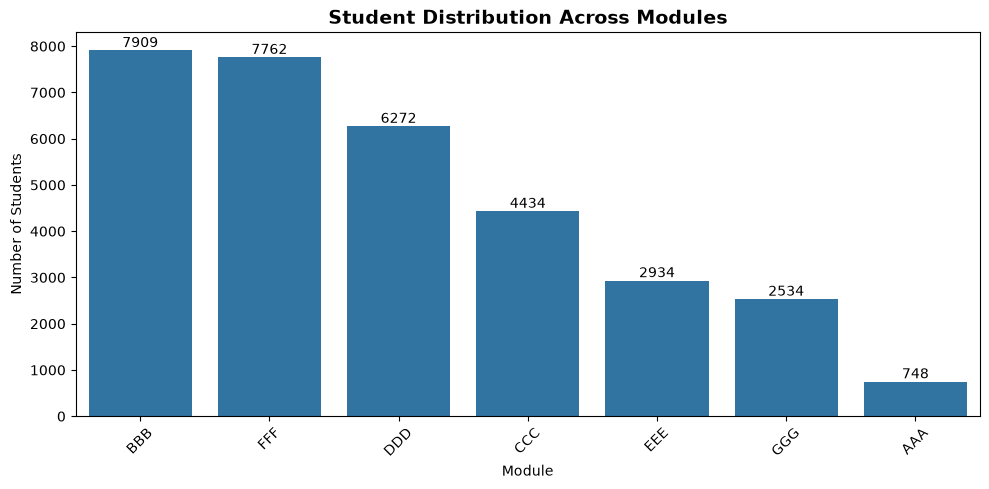

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df_students,
    x='code_module',
    order=df_students['code_module'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Student Distribution Across Modules",
    fontsize=14,
    weight='bold'
)

plt.xlabel("Module")
plt.ylabel("Number of Students")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### 5. Presentation-wise Student Distribution
Observation

Student enrollment differs across course presentations, reflecting variations in course offerings over different academic terms.

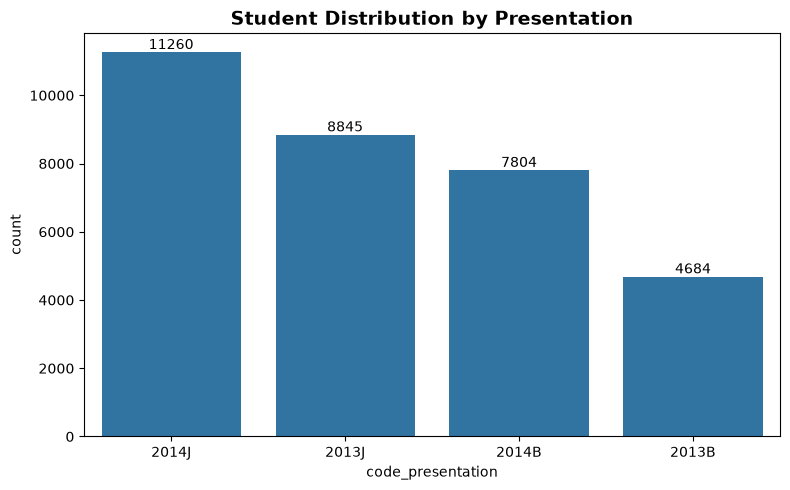

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_students,
    x='code_presentation',
    order=df_students['code_presentation'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Student Distribution by Presentation",
    fontsize=14,
    weight='bold'
)

plt.tight_layout()

plt.show()

### 6. Module vs Final Result
Observation

Academic outcomes vary across modules, with some courses exhibiting higher pass rates while others show comparatively higher withdrawal or failure rates.

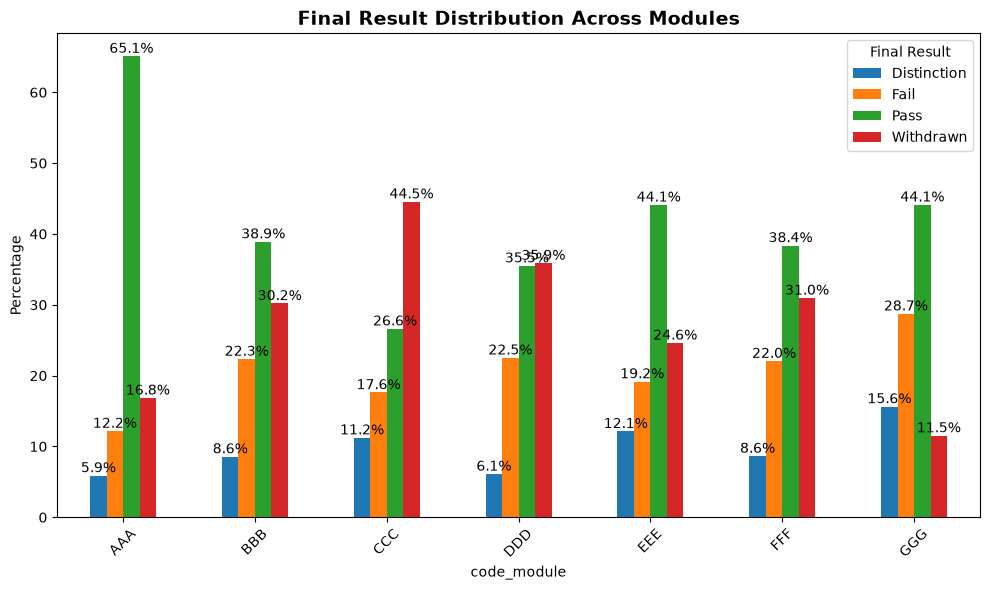

In [ ]:
module_result = pd.crosstab(
    df_students['code_module'],
    df_students['final_result'],
    normalize='index'
) * 100

ax = module_result.plot(
    kind='bar',
    figsize=(10,6)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Final Result Distribution Across Modules",
    fontsize=14,
    weight='bold'
)

plt.ylabel("Percentage")

plt.xticks(rotation=45)

plt.legend(title="Final Result")

plt.tight_layout()

plt.show()

### 7. Assessment Type vs Final Result

Observation

The distribution of final outcomes differs across assessment types, indicating that assessment format may influence student performance.

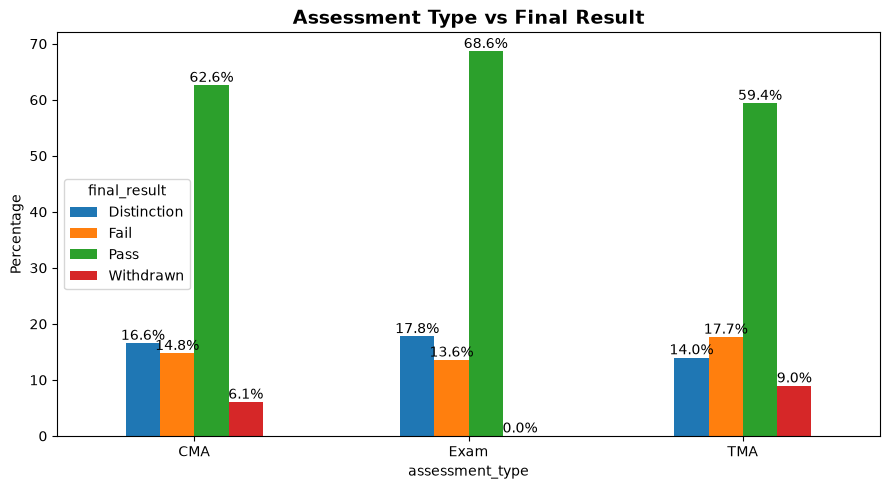

In [ ]:
assessment_result = pd.crosstab(
    merged['assessment_type'],
    merged['final_result'],
    normalize='index'
) * 100

ax = assessment_result.plot(
    kind='bar',
    figsize=(9,5)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title(
    "Assessment Type vs Final Result",
    fontsize=14,
    weight='bold'
)

plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

### 8. Region vs Final Result

Observation

Student outcomes vary slightly across regions, although the differences are less pronounced than those observed for behavioural or academic variables.

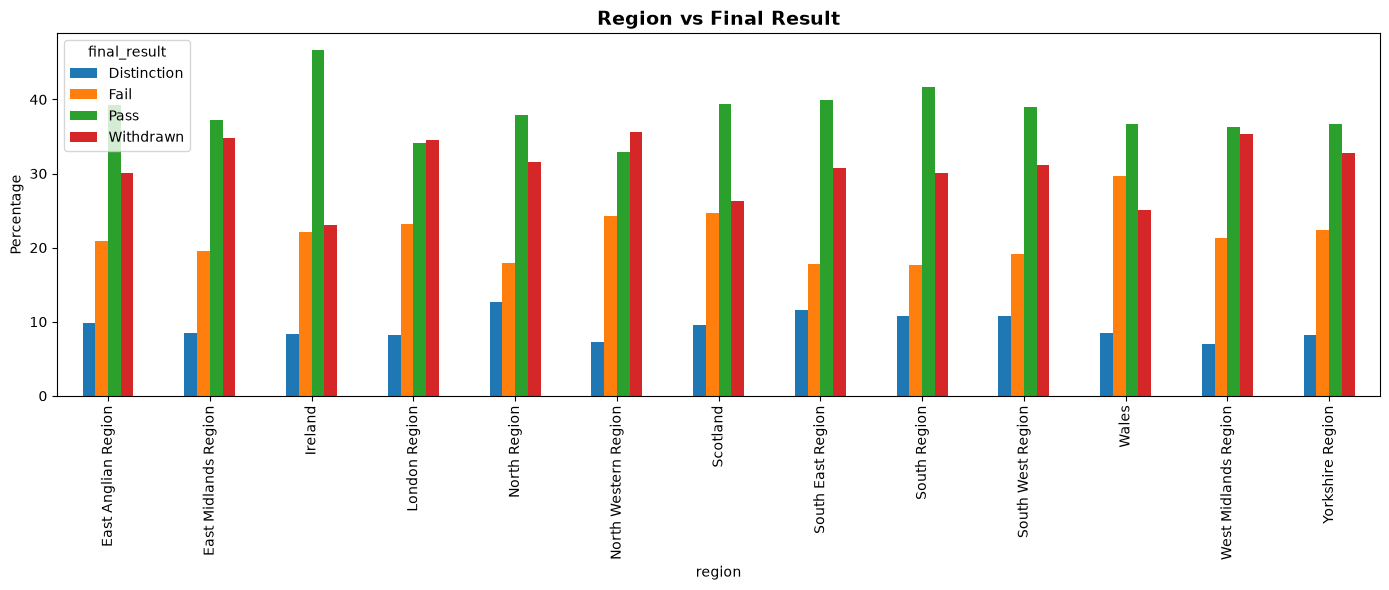

In [ ]:
region_result = pd.crosstab(
    df_students['region'],
    df_students['final_result'],
    normalize='index'
) * 100

region_result.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    "Region vs Final Result",
    fontsize=14,
    weight='bold'
)

plt.ylabel("Percentage")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Overall EDA summary
## Key Findings
Assessment scores are positively associated with successful course completion.
Higher VLE engagement corresponds to better academic outcomes.
Student demographics provide contextual information but appear less influential than behavioural variables.
Registration and withdrawal data indicate varying enrollment patterns.
Missing values are concentrated in expected columns and can be addressed during preprocessing.

This gives a strong transition into Feature Engineering.

# Data Quality Issues Summary
## Data Quality Issues Identified

The exploratory data analysis identified several data quality issues that will be addressed during the Data Preprocessing and Feature Engineering stages.

| Dataset | Issue Identified | Proposed Action |
|----------|-----------------|-----------------|
| studentInfo | 3.41% missing values in `imd_band` | Treat as an "Unknown" category or impute appropriately. |
| studentAssessment | 173 missing assessment scores | Investigate whether these correspond to unsubmitted assessments; impute or exclude if necessary. |
| studentRegistration | 69.10% missing values in `date_unregistration` | Exclude from modeling because it leaks future information. |
| studentRegistration | 45 missing `date_registration` values | Investigate and impute if required. |
| vle | 82.39% missing values in `week_from` and `week_to` | Retain if useful for resource analysis; otherwise exclude from modeling. |
| studentVle | Duplicate interaction records detected | Remove duplicates before creating engagement features. |
| All datasets | Identifier columns (`id_student`, `id_assessment`, etc.) | Retain only for merging; remove before model training. |

### Summary

The datasets are generally of high quality, with relatively few missing values except for variables whose absence is expected (`date_unregistration`, `week_from`, `week_to`). Duplicate records exist primarily in the clickstream dataset and will be handled before feature engineering. Potential target leakage variables have also been identified and will be excluded from the predictive model.


# Potential Features for Feature Engineering

Based on the exploratory data analysis, several variables appear informative for predicting student dropout. These variables will be transformed into meaningful features in the next notebook.

## Demographic Features

- Gender
- Age Band
- Highest Education
- IMD Band
- Disability Status
- Number of Previous Attempts
- Studied Credits

## Assessment Features

- Number of assessments submitted
- Average assessment score
- Weighted assessment score
- Number of missed assessments
- Number of late submissions
- Assessment completion rate

## Registration Features

- Days registered before course start
- Late registration indicator

## VLE Engagement Features

- Total clicks
- Number of active learning days
- Number of distinct learning resources accessed
- Average daily clicks
- Clicks by activity type
- Days since last activity (up to the prediction checkpoint)

## Course Features

- Course duration
- Number of assessments
- Assessment workload

## Target Variable

The final machine learning model will predict whether a student withdraws from the course.

Target encoding:

Withdrawn = 1

All other outcomes (Pass, Fail, Distinction) = 0

## Planned Features

| Available Features (Already Present) | Engineered Features (To Be Created) |
|--------------------------------------|--------------------------------------|
| Gender | Total VLE Clicks |
| Age Band | Number of Active Learning Days |
| Highest Education | Number of Distinct Learning Resources Accessed |
| IMD Band | Average Assessment Score |
| Disability Status | Weighted Assessment Score |
| Number of Previous Attempts | Assessment Completion Rate |
| Studied Credits | Number of Missed Assessments |
| Region | Number of Late Submissions |
| Course Module | Registration Before Course Start |
| Course Duration | Late Registration Indicator |
| Assessment Type | Average Daily Clicks |
| Assessment Weight | Clicks by Activity Type |
| Final Course Outcome (`final_result`) | Binary Dropout Target (`Withdrawn = 1`, Others = 0) |

### Available Features

These variables already exist in the original OULAD datasets and will be used directly after appropriate preprocessing.

### Engineered Features

These variables do not exist directly in the raw datasets. They will be created by aggregating student engagement, assessment performance, and registration information to better represent learning behaviour and improve predictive performance.

## Planned Feature Engineering

| Engineered Feature | Source Dataset(s) | Description |
|--------------------|------------------|-------------|
| Total VLE Clicks | studentVle | Total number of clicks made by each student. |
| Number of Active Learning Days | studentVle | Number of unique days the student accessed the VLE. |
| Number of Distinct Learning Resources Accessed | studentVle + vle | Number of unique learning resources visited. |
| Average Assessment Score | studentAssessment | Mean score across completed assessments. |
| Weighted Assessment Score | studentAssessment + assessments | Assessment score adjusted according to assessment weight. |
| Assessment Completion Rate | studentAssessment + assessments | Percentage of assessments completed. |
| Number of Missed Assessments | studentAssessment + assessments | Assessments not submitted by the student. |
| Number of Late Submissions | studentAssessment + assessments | Assessments submitted after the due date. |
| Registration Before Course Start | studentRegistration | Number of days between registration and course start. |
| Late Registration Indicator | studentRegistration | Indicates whether registration occurred after the course started. |
| Average Daily Clicks | studentVle | Average number of clicks per active learning day. |
| Clicks by Activity Type | studentVle + vle | Student engagement grouped by learning resource type. |
| Binary Dropout Target | studentInfo | Encode `Withdrawn = 1` and `Pass`, `Fail`, `Distinction = 0`. |

# EDA Summary and Next Steps

The exploratory data analysis provided a comprehensive understanding of the OULAD datasets and identified demographic, academic, behavioural, and engagement variables associated with student outcomes. Several data quality issues and potential sources of target leakage were also identified.

The insights obtained from this analysis will guide the next stage of the project, where the datasets will be merged, informative features will be engineered, preprocessing will be performed, and the final modeling dataset will be prepared for machine learning.

## Transition to Feature Engineering

The exploratory data analysis has identified both existing variables and potential engineered features that may improve the prediction of student dropout.

The next notebook focuses on creating these engineered features, merging the OULAD datasets into a unified student-level dataset, removing data leakage, and preparing the final dataset for machine learning.